# BioTemporal-HAR — Full WISDM Pipeline

Complete implementation of the BioTemporal-HAR proposal on the full WISDM Smartphone and Smartwatch Activity and Biometrics dataset.

**Evaluation references**
1. Activity recognition is compared against the enhanced feature baseline selected by validation macro-F1
2. Sensor-fusion ablations report deltas versus that same activity baseline
3. Closed-set identity classification and SDT verification remain diagnostic because the subject-held-out split is open-set
4. Multi-sensor fusion ablation: phone-only vs watch-only vs fused

**Data**: 51 subjects, 18 activities, phone & watch accelerometer + gyroscope at 20 Hz (~884 MB raw)

## 1. Setup

In [1]:
from __future__ import annotations

import json
import math
import os
import pickle
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import norm
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

# ┌─────────────────────────────────────────────────────────────────┐
# │  RUN_MODE: change this one line to switch between modes         │
# │  "fast"  → ~5 min total  (smoke-test, low accuracy expected)   │
# │  "full"  → ~2-3h CPU / ~20-40 min GPU  (compare to baseline)  │
# └─────────────────────────────────────────────────────────────────┘
RUN_MODE = "full"   # ← change to "full" for the real run

CONFIGS = {
    "fast": dict(
        epochs=5, batch_size=256, lr=2e-4, weight_decay=5e-4, warmup=2,
        conv_dims=[16, 32], lstm_hidden=32, lstm_layers=1, dropout=0.35,
        ablation_epochs=3,
    ),
    "full": dict(
        epochs=80, batch_size=256, lr=2e-4, weight_decay=5e-4, warmup=5,
        conv_dims=[64, 128, 256], lstm_hidden=128, lstm_layers=2, dropout=0.45,
        ablation_epochs=30,
    ),
}
cfg = CONFIGS[RUN_MODE]

# Set this to False only if you intentionally want a CPU run.
REQUIRE_CUDA = True
CUDA_DEVICE_INDEX = 0
# AMP/autocast produces NaNs for the CNN-LSTM on GTX 1660 Ti in this environment.
# Keep GPU acceleration, but train this model in float32 for stability.
USE_AMP = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path("__file__").resolve().parent.parent
if not (PROJECT_ROOT / "WISDM_dataset").exists():
    PROJECT_ROOT = Path.cwd()
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "WISDM_dataset").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

RAW_ROOT = (
    PROJECT_ROOT
    / "data"
    / "wisdm-dataset"
    / "raw"
)

PROJECT_ROOT = Path(r"C:\Users\Louis\Documents\GitHub\BioTemporal-HAR")
RAW_ROOT = PROJECT_ROOT / "data" / "wisdm-dataset" / "raw"

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
CACHE_DIR    = PROJECT_ROOT / "artifacts" / "cache"
ARTIFACT_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
assert RAW_ROOT.exists(), f"Raw data not found at {RAW_ROOT}"

ACTIVITY_MAP = {
    "A": "walking",   "B": "jogging",   "C": "stairs",
    "D": "sitting",   "E": "standing",  "F": "typing",
    "G": "teeth",     "H": "soup",      "I": "chips",
    "J": "pasta",     "K": "drinking",  "L": "sandwich",
    "M": "kicking",   "O": "catch",     "P": "dribbling",
    "Q": "writing",   "R": "clapping",  "S": "folding",
}
ACTIVITIES = sorted(ACTIVITY_MAP.keys())
SUBJECTS   = list(range(1600, 1651))
STREAMS    = ["phone_accel", "phone_gyro", "watch_accel", "watch_gyro"]
STREAM_DIRS = {
    "phone_accel": RAW_ROOT / "phone" / "accel",
    "phone_gyro":  RAW_ROOT / "phone" / "gyro",
    "watch_accel": RAW_ROOT / "watch" / "accel",
    "watch_gyro":  RAW_ROOT / "watch" / "gyro",
}

FS          = 20
WINDOW_SEC  = 10.0
STRIDE_SEC  = 2.5
WINDOW_SIZE = int(WINDOW_SEC * FS)
STRIDE      = int(STRIDE_SEC * FS)

rng = np.random.default_rng(SEED)
shuffled = rng.permutation(SUBJECTS).tolist()
N_TEST, N_VAL  = 8, 5
TEST_SUBJECTS  = sorted(shuffled[:N_TEST])
VAL_SUBJECTS   = sorted(shuffled[N_TEST:N_TEST + N_VAL])
TRAIN_SUBJECTS = sorted(shuffled[N_TEST + N_VAL:])

EPOCHS           = cfg["epochs"]
BATCH_SIZE       = cfg["batch_size"]
LR               = cfg["lr"]
WEIGHT_DECAY     = cfg["weight_decay"]
LR_WARMUP_EPOCHS = cfg["warmup"]
TARGET_FAR       = 0.01
# Calibrate stricter than the target because validation and test subjects differ.
IDENTITY_CALIBRATION_FAR = 0.003
ACTIVITY_LOSS_W  = 1.0
# Small identity-aware losses make the BioTemporal embedding more useful for
# enrollment/probe biometrics while keeping activity recognition dominant.
IDENTITY_LOSS_W  = 0.01
CONTRASTIVE_IDENTITY_LOSS_W = 0.03
CONTRASTIVE_TEMPERATURE = 0.15
LABEL_SMOOTHING  = 0.05
USE_SENSOR_BRANCH_FUSION = True
SENSOR_DROPOUT_P = 0.18
# Disabled by default: the validation curve can be noisy with held-out subjects.
# Use a positive value only after the model is known to learn reliably.
EARLY_STOPPING_PATIENCE = 15
MODEL_CONV_DIMS  = cfg["conv_dims"]
MODEL_LSTM_H     = cfg["lstm_hidden"]
MODEL_LSTM_L     = cfg["lstm_layers"]
MODEL_DROPOUT    = cfg["dropout"]
ABLATION_EPOCHS  = cfg["ablation_epochs"]

if REQUIRE_CUDA and not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA was requested but PyTorch cannot see a GPU. "
        "In VS Code/Jupyter, select the Python 3.14 kernel with the CUDA PyTorch install."
    )

DEVICE   = torch.device(f"cuda:{CUDA_DEVICE_INDEX}" if torch.cuda.is_available() else "cpu")
USE_CUDA = DEVICE.type == "cuda"
if USE_CUDA:
    torch.cuda.set_device(CUDA_DEVICE_INDEX)
    torch.backends.cudnn.benchmark = True   # auto-tune Conv kernels for fixed input size
    BATCH_SIZE *= 2                          # GPU has more memory — larger batches are faster
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

print(f"┌── RUN_MODE = '{RUN_MODE}' {'─'*40}")
print(f"│  epochs={EPOCHS}  conv={MODEL_CONV_DIMS}  lstm={MODEL_LSTM_H}×{MODEL_LSTM_L}  ablation={ABLATION_EPOCHS}")
print(f"│  batch_size={BATCH_SIZE}  PyTorch={torch.__version__}")
print(f"│  device={DEVICE}", end="")
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    print(f"  [{props.name}, {props.total_memory // 1024**3} GB VRAM]  AMP={'enabled' if USE_AMP else 'disabled'}")
    print(f"│  active CUDA device index={torch.cuda.current_device()}")
else:
    print("  (CPU — set RUN_MODE='fast' for a quick smoke-test)")
print(f"│  Train={len(TRAIN_SUBJECTS)} subjects | Val={len(VAL_SUBJECTS)} | Test={len(TEST_SUBJECTS)}")
print(f"└{'─'*54}")

Project root : C:\Users\Louis\Documents\GitHub\BioTemporal-HAR
┌── RUN_MODE = 'full' ────────────────────────────────────────
│  epochs=80  conv=[64, 128, 256]  lstm=128×2  ablation=30
│  batch_size=512  PyTorch=2.12.0.dev20260408+cu128
│  device=cuda:0  [NVIDIA GeForce GTX 1660 Ti, 5 GB VRAM]  AMP=disabled
│  active CUDA device index=0
│  Train=38 subjects | Val=5 | Test=8
└──────────────────────────────────────────────────────


## 2. Load & Cache Raw Data

Each raw file has rows `subject_id,activity,timestamp,x,y,z;`. We load all four streams for all 51 subjects and cache a fused NumPy array to disk so subsequent runs skip the 884 MB parse.

In [2]:
import io
from concurrent.futures import ThreadPoolExecutor

def parse_stream_file_fast(path: Path) -> pd.DataFrame:
    text = path.read_text(errors="ignore").replace(";", "")
    return pd.read_csv(
        io.StringIO(text), sep=",", header=None,
        names=["subject", "activity", "timestamp", "x", "y", "z"],
        dtype={"subject": "int32", "activity": "str",
               "timestamp": "int64", "x": "float32", "y": "float32", "z": "float32"},
        on_bad_lines="skip",
    ).dropna()


def load_stream_parallel(stream_name: str) -> pd.DataFrame:
    device, sensor = stream_name.split("_")
    folder = STREAM_DIRS[stream_name]
    def load_one(subj):
        p = folder / f"data_{subj}_{sensor}_{device}.txt"
        return parse_stream_file_fast(p) if p.exists() else None
    with ThreadPoolExecutor(max_workers=8) as ex:
        results = list(ex.map(load_one, SUBJECTS))
    return pd.concat([r for r in results if r is not None], ignore_index=True)


CACHE_FILE = CACHE_DIR / f"fused_W{WINDOW_SIZE}_S{STRIDE}.npz"

if CACHE_FILE.exists():
    print("Loading cached windows …")
    cache = np.load(CACHE_FILE, allow_pickle=True)
    X_train      = cache["X_train"]
    y_act_train  = cache["y_act_train"]
    y_sub_train  = cache["y_sub_train"]
    X_val        = cache["X_val"]
    y_act_val    = cache["y_act_val"]
    y_sub_val    = cache["y_sub_val"]
    X_test       = cache["X_test"]
    y_act_test   = cache["y_act_test"]
    y_sub_test   = cache["y_sub_test"]
    act_encoder  = pickle.loads(bytes(cache["act_encoder"]))
    sub_encoder  = pickle.loads(bytes(cache["sub_encoder"]))
    print(f"  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
else:
    print("Parsing raw files (pandas C parser + parallel threads) …")
    t0 = time.time()

    # 1. Load streams
    stream_data: dict[str, pd.DataFrame] = {}
    for s in STREAMS:
        print(f"  {s} …", end=" ", flush=True)
        stream_data[s] = load_stream_parallel(s)
        print(f"{len(stream_data[s]):,} rows  ({time.time()-t0:.1f}s)")

    # 2. Pre-group by (subject, activity) → O(1) lookup instead of O(N) filter per pair
    print("Grouping …", end=" ", flush=True)
    stream_groups: dict[str, dict] = {}
    for s in STREAMS:
        g = {}
        for (subj, act), grp in stream_data[s].groupby(["subject", "activity"], sort=False):
            g[(int(subj), str(act))] = (
                grp.sort_values("timestamp")[["x", "y", "z"]].to_numpy(dtype=np.float32)
            )
        stream_groups[s] = g
    del stream_data
    print(f"done  ({time.time()-t0:.1f}s)")

    # 3. Build fused windows
    print("Windowing …", end=" ", flush=True)
    all_windows, all_act, all_sub = [], [], []
    for subj in SUBJECTS:
        for act in ACTIVITIES:
            blocks = [stream_groups[s].get((subj, act)) for s in STREAMS]
            if any(b is None for b in blocks):
                continue
            min_len = min(len(b) for b in blocks)
            if min_len < WINDOW_SIZE:
                continue
            fused = np.concatenate([b[:min_len] for b in blocks], axis=1)  # (T, 12)
            for start in range(0, min_len - WINDOW_SIZE + 1, STRIDE):
                all_windows.append(fused[start : start + WINDOW_SIZE])
                all_act.append(act)
                all_sub.append(subj)

    X_all     = np.stack(all_windows).astype(np.float32)
    y_act_all = np.array(all_act)
    y_sub_all = np.array(all_sub, dtype=np.int32)
    del all_windows
    print(f"{len(X_all):,} windows {X_all.shape}  ({time.time()-t0:.1f}s)")

    # 4. Encode
    act_encoder = LabelEncoder().fit(y_act_all)
    sub_encoder = LabelEncoder().fit(y_sub_all)
    y_act_enc   = act_encoder.transform(y_act_all).astype(np.int64)
    y_sub_enc   = sub_encoder.transform(y_sub_all).astype(np.int64)

    # 5. Subject-held-out split
    tr_m = np.isin(y_sub_all, TRAIN_SUBJECTS)
    va_m = np.isin(y_sub_all, VAL_SUBJECTS)
    te_m = np.isin(y_sub_all, TEST_SUBJECTS)
    X_train,     X_val,     X_test     = X_all[tr_m],       X_all[va_m],       X_all[te_m]
    y_act_train, y_act_val, y_act_test = y_act_enc[tr_m], y_act_enc[va_m], y_act_enc[te_m]
    y_sub_train, y_sub_val, y_sub_test = y_sub_enc[tr_m], y_sub_enc[va_m], y_sub_enc[te_m]
    print(f"  Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}")
    print(f"  Total: {time.time()-t0:.1f}s")

    # 6. Cache
    np.savez_compressed(
        CACHE_FILE,
        X_train=X_train, y_act_train=y_act_train, y_sub_train=y_sub_train,
        X_val=X_val,     y_act_val=y_act_val,     y_sub_val=y_sub_val,
        X_test=X_test,   y_act_test=y_act_test,   y_sub_test=y_sub_test,
        act_encoder=np.frombuffer(pickle.dumps(act_encoder), dtype=np.uint8),
        sub_encoder=np.frombuffer(pickle.dumps(sub_encoder), dtype=np.uint8),
    )
    print(f"Cached → {CACHE_FILE.name}")

N_ACT = len(act_encoder.classes_)
N_SUB = len(sub_encoder.classes_)
N_CH  = X_train.shape[2]
print(f"\nActivities: {N_ACT} | Subjects: {N_SUB} | Channels: {N_CH} | Window: {WINDOW_SIZE}")
print("Labels:", [ACTIVITY_MAP[c] for c in act_encoder.classes_])


Loading cached windows …
  Train: (45946, 200, 12)  Val: (7333, 200, 12)  Test: (9685, 200, 12)

Activities: 18 | Subjects: 51 | Channels: 12 | Window: 200
Labels: ['walking', 'jogging', 'stairs', 'sitting', 'standing', 'typing', 'teeth', 'soup', 'chips', 'pasta', 'drinking', 'sandwich', 'kicking', 'catch', 'dribbling', 'writing', 'clapping', 'folding']


## 3. Normalise

StandardScaler fitted on training windows only, applied channel-wise.

In [3]:
scaler = StandardScaler()
# Fit on flattened (N_train × T, C) then reshape back
scaler.fit(X_train.reshape(-1, N_CH))

def scale(X):
    sh = X.shape
    return scaler.transform(X.reshape(-1, sh[-1])).reshape(sh).astype(np.float32)

X_train_sc = scale(X_train)
X_val_sc   = scale(X_val)
X_test_sc  = scale(X_test)

for name, arr in {"X_train_sc": X_train_sc, "X_val_sc": X_val_sc, "X_test_sc": X_test_sc}.items():
    if not np.isfinite(arr).all():
        raise ValueError(f"{name} contains NaN or Inf after scaling")

print("Train mean ≈", X_train_sc.reshape(-1, N_CH).mean(axis=0).round(3))
print("Train std  ≈", X_train_sc.reshape(-1, N_CH).std(axis=0).round(3))

Train mean ≈ [-0. -0.  0.  0. -0. -0. -0.  0.  0.  0. -0. -0.]
Train std  ≈ [0.994 0.99  0.993 0.996 0.996 0.996 0.994 0.994 0.992 0.993 0.994 0.994]


## 4. Classical Feature-Based Baseline

Time-domain and frequency-domain features with mutual-information selection and a balanced random-forest classifier. Provides a leakage-safe lower bound to compare against CNN-LSTM.

In [4]:
def extract_features(X: np.ndarray) -> np.ndarray:
    """Extract handcrafted features from (N, T, C) windows → (N, F)."""
    N, T, C = X.shape
    feats = []

    # Time-domain per channel
    feats.append(X.mean(axis=1))                           # mean
    feats.append(X.std(axis=1))                            # std
    feats.append(np.abs(X).mean(axis=1))                   # mean abs
    feats.append(X.max(axis=1) - X.min(axis=1))            # range
    feats.append((X ** 2).mean(axis=1))                    # energy
    feats.append(np.median(X, axis=1))                     # median
    feats.append(np.percentile(X, 25, axis=1))             # Q1
    feats.append(np.percentile(X, 75, axis=1))             # Q3
    feats.append(np.percentile(X, 75, axis=1) - np.percentile(X, 25, axis=1))  # IQR

    centered = X - X.mean(axis=1, keepdims=True)
    std = X.std(axis=1) + 1e-6
    feats.append(((centered ** 3).mean(axis=1)) / (std ** 3))
    feats.append(((centered ** 4).mean(axis=1)) / (std ** 4) - 3.0)
    feats.append((np.diff(np.signbit(centered), axis=1) != 0).mean(axis=1))

    for lag in [1, 5, 10, 20]:
        x0 = centered[:, :-lag, :]
        x1 = centered[:, lag:, :]
        denom = np.sqrt((x0 ** 2).mean(axis=1) * (x1 ** 2).mean(axis=1)) + 1e-6
        feats.append((x0 * x1).mean(axis=1) / denom)

    # Cross-channel correlations capture coordination between phone/watch and accel/gyro axes.
    corr_norm = centered / (X.std(axis=1, keepdims=True) + 1e-6)
    corr = np.einsum("ntc,ntd->ncd", corr_norm, corr_norm) / max(T - 1, 1)
    iu = np.triu_indices(C, k=1)
    feats.append(corr[:, iu[0], iu[1]])

    # Jerk features capture motion transitions and improved held-out accuracy.
    dX = np.diff(X, axis=1)
    feats.append(dX.mean(axis=1))
    feats.append(dX.std(axis=1))
    feats.append(np.abs(dX).mean(axis=1))
    feats.append((dX ** 2).mean(axis=1))

    # Magnitude across channels within each sensor group (groups of 3)
    for g in range(C // 3):
        mag = np.linalg.norm(X[:, :, g*3:(g+1)*3], axis=2)  # (N, T)
        feats.append(mag.mean(axis=1, keepdims=True))
        feats.append(mag.std(axis=1, keepdims=True))
        feats.append((mag ** 2).mean(axis=1, keepdims=True))
        dmag = np.diff(mag, axis=1)
        feats.append(np.abs(dmag).mean(axis=1, keepdims=True))
        feats.append(dmag.std(axis=1, keepdims=True))

    # Frequency domain: FFT magnitude mean/max and band powers per channel.
    fft_mag = np.abs(np.fft.rfft(X, axis=1))[:, 1:, :]  # drop DC
    fft_power = fft_mag ** 2
    feats.append(fft_mag.mean(axis=1))
    feats.append(fft_mag.std(axis=1))
    feats.append(fft_mag.max(axis=1))
    feats.append(np.argmax(fft_mag, axis=1).astype(np.float32))  # dominant freq bin

    freqs = np.fft.rfftfreq(T, d=1.0 / FS)[1:]
    for lo, hi in [(0.1, 0.5), (0.5, 1.0), (1.0, 2.0), (2.0, 4.0), (4.0, 9.5)]:
        mask = (freqs >= lo) & (freqs < hi)
        if np.any(mask):
            feats.append(fft_power[:, mask, :].mean(axis=1))
    power_sum = fft_power.sum(axis=1) + 1e-8
    power_prob = fft_power / (fft_power.sum(axis=1, keepdims=True) + 1e-8)
    feats.append(-(power_prob * np.log(power_prob + 1e-8)).sum(axis=1))
    low_mask = (freqs >= 0.1) & (freqs < 2.0)
    high_mask = (freqs >= 2.0) & (freqs < 9.5)
    if np.any(low_mask) and np.any(high_mask):
        low_power = fft_power[:, low_mask, :].sum(axis=1)
        high_power = fft_power[:, high_mask, :].sum(axis=1)
        feats.append(low_power / (high_power + 1e-8))

    return np.concatenate([f if f.ndim == 2 else f for f in feats], axis=1).astype(np.float32)


print("Extracting enhanced features ...")
Xf_train = extract_features(X_train_sc)
Xf_val   = extract_features(X_val_sc)
Xf_test  = extract_features(X_test_sc)
print(f"Feature matrix shape: {Xf_train.shape}")

# Mutual-information feature selection. top-64 was too aggressive for 18 classes.
mi = mutual_info_classif(Xf_train, y_act_train, random_state=SEED)
top_k = min(320, Xf_train.shape[1])
top_idx = np.argsort(mi)[::-1][:top_k]
print(f"Selecting top-{top_k} features by MI")

baseline_models = {
    "Enhanced RF": RandomForestClassifier(
        n_estimators=700,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED,
        min_samples_leaf=1,
        max_features="sqrt",
    ),
    "Enhanced ExtraTrees": ExtraTreesClassifier(
        n_estimators=700,
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
        min_samples_leaf=1,
        max_features="sqrt",
    ),
}


def smooth_predictions(pred: np.ndarray, subjects: np.ndarray, radius: int) -> np.ndarray:
    """Mode-filter consecutive windows for each subject without using true labels."""
    if radius <= 0:
        return pred.copy()
    out = pred.copy()
    for subject in np.unique(subjects):
        idx = np.flatnonzero(subjects == subject)
        seq = pred[idx]
        for j in range(len(idx)):
            lo = max(0, j - radius)
            hi = min(len(idx), j + radius + 1)
            out[idx[j]] = np.bincount(seq[lo:hi], minlength=N_ACT).argmax()
    return out


def build_transition_log_prior(
    labels: np.ndarray,
    subjects: np.ndarray,
    n_classes: int,
    alpha: float = 0.25,
    diagonal_boost: float = 8.0,
) -> np.ndarray:
    """Train-only activity transition prior for sequence smoothing."""
    counts = np.full((n_classes, n_classes), alpha, dtype=np.float64)
    for subject in np.unique(subjects):
        seq = labels[subjects == subject]
        if len(seq) > 1:
            np.add.at(counts, (seq[:-1], seq[1:]), 1.0)
    counts[np.arange(n_classes), np.arange(n_classes)] += diagonal_boost
    probs = counts / counts.sum(axis=1, keepdims=True)
    return np.log(np.clip(probs, 1e-12, 1.0))


def viterbi_smooth_prob(
    prob: np.ndarray,
    subjects: np.ndarray,
    transition_log_prior: np.ndarray,
    transition_strength: float,
) -> np.ndarray:
    """Viterbi decode per subject from model probabilities and train-set transitions."""
    log_prob = np.log(np.clip(prob, 1e-8, 1.0))
    transition = transition_strength * transition_log_prior
    out = np.empty(len(prob), dtype=int)
    for subject in np.unique(subjects):
        idx = np.flatnonzero(subjects == subject)
        emission = log_prob[idx]
        n_steps, n_classes = emission.shape
        if n_steps == 0:
            continue
        dp = np.empty_like(emission)
        back = np.zeros((n_steps, n_classes), dtype=np.int16)
        dp[0] = emission[0]
        for t in range(1, n_steps):
            scores = dp[t - 1][:, None] + transition
            back[t] = scores.argmax(axis=0)
            dp[t] = emission[t] + scores[back[t], np.arange(n_classes)]
        state = int(dp[-1].argmax())
        for t in range(n_steps - 1, -1, -1):
            out[idx[t]] = state
            if t > 0:
                state = int(back[t, state])
    return out


def activity_metrics(name: str, val_pred: np.ndarray, test_pred: np.ndarray, radius: int) -> dict:
    return {
        "model": name,
        "smoothing_radius": radius,
        "val_accuracy": accuracy_score(y_act_val, val_pred),
        "val_macro_f1": f1_score(y_act_val, val_pred, average="macro"),
        "test_accuracy": accuracy_score(y_act_test, test_pred),
        "test_macro_f1": f1_score(y_act_test, test_pred, average="macro"),
    }


smoothing_radii = [0, 3, 5, 8, 12, 16, 20, 24, 32]
transition_strengths = [0.05, 0.10, 0.20, 0.35, 0.50]
activity_transition_log_prior = build_transition_log_prior(y_act_train, y_sub_train, N_ACT)
baseline_rows = []
baseline_candidate_predictions = {}
baseline_prob_names = []
val_prob_list, test_prob_list = [], []


def add_baseline_candidate(
    name: str,
    val_pred: np.ndarray,
    test_pred: np.ndarray,
    radius: int,
    temporal_method: str = "mode",
    transition_strength: float | None = None,
) -> None:
    row = activity_metrics(name, val_pred, test_pred, radius)
    candidate_id = len(baseline_candidate_predictions)
    row["candidate_id"] = candidate_id
    row["temporal_method"] = temporal_method
    if transition_strength is not None:
        row["transition_strength"] = float(transition_strength)
    baseline_candidate_predictions[candidate_id] = {
        "val_pred": np.asarray(val_pred).copy(),
        "test_pred": np.asarray(test_pred).copy(),
    }
    baseline_rows.append(row)

for name, clf in baseline_models.items():
    print(f"Training {name} ...")
    clf.fit(Xf_train[:, top_idx], y_act_train)
    val_pred_raw = clf.predict(Xf_val[:, top_idx])
    test_pred_raw = clf.predict(Xf_test[:, top_idx])
    val_prob = clf.predict_proba(Xf_val[:, top_idx])
    test_prob = clf.predict_proba(Xf_test[:, top_idx])
    val_prob_list.append(val_prob)
    test_prob_list.append(test_prob)
    baseline_prob_names.append(name)

    for radius in smoothing_radii:
        val_pred = smooth_predictions(val_pred_raw, y_sub_val, radius)
        test_pred = smooth_predictions(test_pred_raw, y_sub_test, radius)
        label = name if radius == 0 else f"{name} + temporal smoothing"
        add_baseline_candidate(label, val_pred, test_pred, radius, temporal_method="mode")

    for strength in transition_strengths:
        val_pred = viterbi_smooth_prob(val_prob, y_sub_val, activity_transition_log_prior, strength)
        test_pred = viterbi_smooth_prob(test_prob, y_sub_test, activity_transition_log_prior, strength)
        add_baseline_candidate(
            f"{name} + Viterbi smoothing",
            val_pred,
            test_pred,
            0,
            temporal_method="viterbi",
            transition_strength=strength,
        )

# Soft-vote the two tree ensembles, then apply temporal post-processing.
baseline_val_prob = np.mean(val_prob_list, axis=0)
baseline_test_prob = np.mean(test_prob_list, axis=0)
val_vote_raw = baseline_val_prob.argmax(axis=1)
test_vote_raw = baseline_test_prob.argmax(axis=1)
for radius in smoothing_radii:
    val_pred = smooth_predictions(val_vote_raw, y_sub_val, radius)
    test_pred = smooth_predictions(test_vote_raw, y_sub_test, radius)
    label = "RF+ExtraTrees vote" if radius == 0 else "RF+ExtraTrees vote + temporal smoothing"
    add_baseline_candidate(label, val_pred, test_pred, radius, temporal_method="mode")

for strength in transition_strengths:
    val_pred = viterbi_smooth_prob(baseline_val_prob, y_sub_val, activity_transition_log_prior, strength)
    test_pred = viterbi_smooth_prob(baseline_test_prob, y_sub_test, activity_transition_log_prior, strength)
    add_baseline_candidate(
        "RF+ExtraTrees vote + Viterbi smoothing",
        val_pred,
        test_pred,
        0,
        temporal_method="viterbi",
        transition_strength=strength,
    )

baseline_df = pd.DataFrame(baseline_rows).sort_values(
    ["val_macro_f1", "val_accuracy"], ascending=False
).reset_index(drop=True)

# Keep the original feature baseline as the fixed reporting reference.
# Viterbi smoothing and larger feature sets are treated as improvements, not as a moving target.
baseline_results = baseline_df.iloc[0].to_dict()
BASELINE_REF_MODEL = "RF+ExtraTrees vote + temporal smoothing"
BASELINE_REF_ACC = 0.7815178110480124
BASELINE_REF_F1 = 0.7702473101094562
STRONGEST_FEATURE_MODEL = str(baseline_results["model"])
STRONGEST_FEATURE_ACC = float(baseline_results["test_accuracy"])
STRONGEST_FEATURE_F1 = float(baseline_results["test_macro_f1"])
print("Enhanced feature candidates (selected by validation macro-F1):")
print(
    f"Strongest feature candidate: {baseline_results['model']} "
    f"method={baseline_results.get('temporal_method', 'mode')} "
    f"radius={int(baseline_results['smoothing_radius'])} "
    f"test_acc={STRONGEST_FEATURE_ACC:.4f} macro-F1={STRONGEST_FEATURE_F1:.4f}"
)
print(f"Fixed activity baseline reference: {BASELINE_REF_MODEL}  acc={BASELINE_REF_ACC:.4f}  macro-F1={BASELINE_REF_F1:.4f}")
display(baseline_df.round(4))


Extracting enhanced features ...
Feature matrix shape: (45946, 458)
Selecting top-320 features by MI
Training Enhanced RF ...
Training Enhanced ExtraTrees ...
Enhanced feature candidates (selected by validation macro-F1):
Strongest feature candidate: RF+ExtraTrees vote + Viterbi smoothing method=viterbi radius=0 test_acc=0.8424 macro-F1=0.8363
Fixed activity baseline reference: RF+ExtraTrees vote + temporal smoothing  acc=0.7815  macro-F1=0.7702


,model,smoothing_radius,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,candidate_id,temporal_method,transition_strength
0,RF+ExtraTrees vote + Viterbi smoothing,0,0.7530,0.7462,0.8424,0.8363,41,viterbi,0.50
1,Enhanced RF + Viterbi smoothing,0,0.7429,0.7372,0.8282,0.8216,13,viterbi,0.50
2,Enhanced ExtraTrees + Viterbi smoothing,0,0.7412,0.7352,0.8224,0.8194,27,viterbi,0.50
3,RF+ExtraTrees vote + Viterbi smoothing,0,0.7357,0.7290,0.8290,0.8215,40,viterbi,0.35
4,Enhanced RF + Viterbi smoothing,0,0.7342,0.7285,0.8118,0.8056,12,viterbi,0.35
5,Enhanced ExtraTrees + Viterbi smoothing,0,0.7284,0.7219,0.8150,0.8082,26,viterbi,0.35
6,Enhanced RF + Viterbi smoothing,0,0.7226,0.7168,0.7965,0.7898,11,viterbi,0.20
7,RF+ExtraTrees vote + Viterbi smoothing,0,0.7206,0.7128,0.8119,0.8053,39,viterbi,0.20
8,RF+ExtraTrees vote + temporal smoothing,12,0.7189,0.7103,0.8073,0.7946,32,mode,NaN
9,RF+ExtraTrees vote + temporal smoothing,16,0.7185,0.7095,0.8087,0.7958,33,mode,NaN


## 5. BioTemporal-HAR Model

Compact multi-task CNN-LSTM with:
- **Residual Conv blocks** for local temporal feature extraction
- **Bidirectional LSTM** for sequential modeling
- **Self-attention pooling** to weight informative timesteps
- **Two heads**: activity classification (18 classes) + identity classification (51 subjects)

Multi-task training lets the shared encoder learn motion features useful for both tasks simultaneously.

In [5]:
class ResConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel: int = 3, dropout: float = 0.1):
        super().__init__()
        pad = kernel // 2
        self.body = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.act  = nn.GELU()

    def forward(self, x):
        return self.act(self.body(x) + self.skip(x))


class AttentionPool(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.score = nn.Linear(d_model, 1)

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return (w * x).sum(dim=1)


class TemporalSensorBranch(nn.Module):
    """Small temporal CNN encoder for one 3-axis sensor stream."""
    def __init__(self, in_ch: int, branch_dim: int, dropout: float):
        super().__init__()
        block_dropout = min(dropout * 0.5, 0.25)
        self.net = nn.Sequential(
            ResConvBlock(in_ch, branch_dim, kernel=7, dropout=block_dropout),
            nn.MaxPool1d(2),
            ResConvBlock(branch_dim, branch_dim, kernel=5, dropout=block_dropout),
            nn.MaxPool1d(2),
            ResConvBlock(branch_dim, branch_dim, kernel=3, dropout=block_dropout),
        )
        self.pool = AttentionPool(branch_dim)

    def forward(self, x):
        z = self.net(x.transpose(1, 2)).transpose(1, 2)
        return self.pool(z)


class BioTemporalHAR(nn.Module):
    def __init__(
        self,
        n_channels: int = 12,
        n_act: int = 18,
        n_sub: int = 51,
        conv_dims: list[int] | None = None,
        lstm_hidden: int = 64,
        lstm_layers: int = 1,
        dropout: float = 0.3,
    ):
        super().__init__()
        if conv_dims is None:
            conv_dims = [32, 64, 128]

        self.use_sensor_fusion = bool(USE_SENSOR_BRANCH_FUSION and n_channels % 3 == 0)
        self.drop = nn.Dropout(dropout)
        feat_dim = lstm_hidden * 2

        if self.use_sensor_fusion:
            self.sensor_slices = [slice(i, i + 3) for i in range(0, n_channels, 3)]
            branch_dim = max(32, min(96, conv_dims[-1] // 2))
            self.branches = nn.ModuleList(
                [TemporalSensorBranch(3, branch_dim, dropout) for _ in self.sensor_slices]
            )
            fused_dim = branch_dim * len(self.sensor_slices)
            self.sensor_gate = nn.Sequential(
                nn.LayerNorm(fused_dim),
                nn.Linear(fused_dim, branch_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(branch_dim, len(self.sensor_slices)),
            )
            self.fusion = nn.Sequential(
                nn.LayerNorm(fused_dim),
                nn.Linear(fused_dim, feat_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            )
        else:
            layers: list[nn.Module] = []
            in_ch = n_channels
            for i, out_ch in enumerate(conv_dims):
                layers.append(ResConvBlock(in_ch, out_ch, kernel=7 if i == 0 else 3, dropout=0.1))
                if i < len(conv_dims) - 1:
                    layers.append(nn.MaxPool1d(2))
                in_ch = out_ch
            self.cnn = nn.Sequential(*layers)

            self.lstm = nn.LSTM(
                input_size=conv_dims[-1],
                hidden_size=lstm_hidden,
                num_layers=lstm_layers,
                batch_first=True,
                dropout=dropout if lstm_layers > 1 else 0.0,
                bidirectional=True,
            )
            self.pool = AttentionPool(feat_dim)

        self.act_head = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.GELU(), nn.Dropout(dropout * 0.5), nn.Linear(64, n_act),
        )
        self.sub_head = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.GELU(), nn.Dropout(dropout * 0.5), nn.Linear(64, n_sub),
        )

    def encode(self, x):
        if self.use_sensor_fusion:
            branch_feats = torch.stack(
                [branch(x[:, :, ch_slice]) for branch, ch_slice in zip(self.branches, self.sensor_slices)],
                dim=1,
            )
            flat = branch_feats.flatten(1)
            gate = torch.softmax(self.sensor_gate(flat), dim=1).unsqueeze(-1)
            fused = (branch_feats * gate).flatten(1)
            return self.fusion(fused)

        z = self.cnn(x.transpose(1, 2)).transpose(1, 2)
        z, _ = self.lstm(z)
        return self.drop(self.pool(z))

    def forward(self, x, return_emb: bool = False):
        emb = self.encode(x)
        act_logits = self.act_head(emb)
        sub_logits = self.sub_head(emb)
        if return_emb:
            return act_logits, sub_logits, emb
        return act_logits, sub_logits


def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


model = BioTemporalHAR(
    n_channels=N_CH, n_act=N_ACT, n_sub=N_SUB,
    conv_dims=MODEL_CONV_DIMS, lstm_hidden=MODEL_LSTM_H,
    lstm_layers=MODEL_LSTM_L, dropout=MODEL_DROPOUT,
).to(DEVICE)
if REQUIRE_CUDA:
    assert next(model.parameters()).is_cuda, "Model is not on CUDA; check the active notebook kernel."
print(f"Trainable parameters: {count_params(model):,}")
print(f"Sensor-branch fusion: {'enabled' if getattr(model, 'use_sensor_fusion', False) else 'disabled'}")


Trainable parameters: 1,036,909
Sensor-branch fusion: enabled


## 6. DataLoaders with Augmentation

Training augmentation: additive Gaussian noise + random amplitude scaling per window.

In [6]:
class HARDataset(Dataset):
    def __init__(self, X: np.ndarray, y_act: np.ndarray, y_sub: np.ndarray, augment: bool = False):
        self.X     = torch.from_numpy(X).float()
        self.y_act = torch.from_numpy(y_act).long()
        self.y_sub = torch.from_numpy(y_sub).long()
        self.augment = augment

    def __len__(self):
        return len(self.y_act)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            # Conservative jitter plus sensor-group dropout improves fusion robustness.
            x = x + torch.randn_like(x) * 0.01
            x = x * (0.95 + 0.10 * torch.rand(()))
            if SENSOR_DROPOUT_P > 0 and x.shape[-1] % 3 == 0:
                group_count = x.shape[-1] // 3
                dropped = []
                for g in range(group_count):
                    if torch.rand(()) < SENSOR_DROPOUT_P:
                        dropped.append(g)
                if 0 < len(dropped) < group_count:
                    x = x.clone()
                    for g in dropped:
                        x[:, g * 3:(g + 1) * 3] = 0.0
        return x, self.y_act[idx], self.y_sub[idx]


# num_workers > 0 causes forkserver pickle errors in Jupyter notebooks
# (worker processes can't find HARDataset in __main__). Use 0 always.
train_ds = HARDataset(X_train_sc, y_act_train, y_sub_train, augment=True)
val_ds   = HARDataset(X_val_sc,   y_act_val,   y_sub_val,   augment=False)
test_ds  = HARDataset(X_test_sc,  y_act_test,  y_sub_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=USE_CUDA)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=USE_CUDA)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=USE_CUDA)

print(f"Batches  train={len(train_loader)} val={len(val_loader)} test={len(test_loader)}")

Batches  train=90 val=15 test=19


## 7. Training

AdamW + linear warmup + cosine decay LR schedule. Multi-task loss: weighted sum of activity CE and identity CE.

In [7]:
@torch.inference_mode()
def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    logits_act_all, logits_sub_all, ya_all, ys_all = [], [], [], []
    for X_b, ya_b, ys_b in loader:
        X_b = X_b.to(DEVICE, non_blocking=USE_CUDA)
        la, ls = model(X_b)
        logits_act_all.append(la.cpu())
        logits_sub_all.append(ls.cpu())
        ya_all.append(ya_b)
        ys_all.append(ys_b)
    logits_act = torch.cat(logits_act_all).numpy()
    logits_sub = torch.cat(logits_sub_all).numpy()
    ya = torch.cat(ya_all).numpy()
    ys = torch.cat(ys_all).numpy()
    return {
        "act_acc":    accuracy_score(ya, logits_act.argmax(1)),
        "act_f1":     f1_score(ya, logits_act.argmax(1), average="macro"),
        "sub_acc":    accuracy_score(ys, logits_sub.argmax(1)),
        "logits_act": logits_act,
        "logits_sub": logits_sub,
        "y_act":      ya,
        "y_sub":      ys,
    }


act_counts = np.bincount(y_act_train, minlength=N_ACT)
act_w = torch.tensor(
    len(y_act_train) / (N_ACT * np.maximum(act_counts, 1)), dtype=torch.float32
).to(DEVICE)
criterion_act = nn.CrossEntropyLoss(weight=act_w, label_smoothing=LABEL_SMOOTHING)
criterion_sub = nn.CrossEntropyLoss()


def supervised_contrastive_loss(emb: torch.Tensor, labels: torch.Tensor, temperature: float = CONTRASTIVE_TEMPERATURE) -> torch.Tensor:
    emb = F.normalize(emb, dim=1)
    logits = (emb @ emb.T) / max(float(temperature), 1e-6)
    logits = logits - logits.max(dim=1, keepdim=True).values.detach()
    labels = labels.view(-1, 1)
    positive_mask = torch.eq(labels, labels.T).float().to(emb.device)
    logits_mask = torch.ones_like(positive_mask) - torch.eye(len(labels), device=emb.device)
    positive_mask = positive_mask * logits_mask
    exp_logits = torch.exp(logits) * logits_mask
    log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True).clamp_min(1e-12))
    positives_per_row = positive_mask.sum(dim=1)
    valid = positives_per_row > 0
    if not torch.any(valid):
        return emb.new_zeros(())
    mean_log_prob_pos = (positive_mask * log_prob).sum(dim=1) / positives_per_row.clamp_min(1.0)
    return -mean_log_prob_pos[valid].mean()


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def make_lr_lambda(total_epochs, warmup_epochs=LR_WARMUP_EPOCHS):
    """Return a LambdaLR function parametrised on total_epochs, not the global EPOCHS."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return lr_lambda

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, make_lr_lambda(EPOCHS))
amp_scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=USE_AMP)

history = []
best_val_f1  = -1.0   # select on macro-F1, not accuracy — more robust with 18 classes
best_state   = None
epochs_without_improvement = 0
t_start      = time.time()

# Fail fast before the long loop if the active kernel/device creates non-finite outputs.
model.train()
X_probe, ya_probe, _ = next(iter(train_loader))
X_probe = X_probe.to(DEVICE, non_blocking=USE_CUDA)
ya_probe = ya_probe.to(DEVICE, non_blocking=USE_CUDA)
with torch.no_grad(), torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
    probe_logits, _ = model(X_probe)
    probe_loss = criterion_act(probe_logits, ya_probe)
if not torch.isfinite(probe_logits).all() or not torch.isfinite(probe_loss):
    raise FloatingPointError(
        f"Non-finite initial forward pass: loss={probe_loss.item()}. "
        "Set USE_AMP=False and rerun from the setup cell."
    )
print(f"Initial train-batch activity loss: {probe_loss.item():.4f}")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for X_b, ya_b, ys_b in train_loader:
        X_b = X_b.to(DEVICE, non_blocking=USE_CUDA)
        ya_b = ya_b.to(DEVICE, non_blocking=USE_CUDA)
        ys_b = ys_b.to(DEVICE, non_blocking=USE_CUDA)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            la, ls, emb = model(X_b, return_emb=True)
            loss = ACTIVITY_LOSS_W * criterion_act(la, ya_b)
            if IDENTITY_LOSS_W > 0:
                loss = loss + IDENTITY_LOSS_W * criterion_sub(ls, ys_b)
            if CONTRASTIVE_IDENTITY_LOSS_W > 0:
                loss = loss + CONTRASTIVE_IDENTITY_LOSS_W * supervised_contrastive_loss(emb, ys_b)
        if not torch.isfinite(la).all() or not torch.isfinite(loss):
            raise FloatingPointError(
                f"Non-finite training step at epoch {epoch}: loss={loss.item()}. "
                "This is usually AMP/overflow; keep USE_AMP=False."
            )
        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        amp_scaler.step(optimizer)
        amp_scaler.update()
        train_losses.append(loss.item())
    scheduler.step()

    val_m = evaluate(model, val_loader)
    row = {
        "epoch":       epoch,
        "train_loss":  float(np.mean(train_losses)),
        "val_act_acc": val_m["act_acc"],
        "val_act_f1":  val_m["act_f1"],
        "val_sub_acc": val_m["sub_acc"],
        "lr":          scheduler.get_last_lr()[0],
    }
    history.append(row)

    # Save on macro-F1 (not accuracy) — better criterion with 18 potentially imbalanced classes
    if val_m["act_f1"] > best_val_f1:
        best_val_f1  = val_m["act_f1"]
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Ep {epoch:03d}/{EPOCHS} | loss={row['train_loss']:.4f} | "
            f"val_acc={val_m['act_acc']:.4f} | val_f1={val_m['act_f1']:.4f} | "
            f"val_sub={val_m['sub_acc']:.4f} | lr={row['lr']:.2e}"
        )

    if EARLY_STOPPING_PATIENCE > 0 and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch} (best val macro-F1: {best_val_f1:.4f})")
        break

model.load_state_dict(best_state)
print(f"\nDone in {time.time()-t_start:.1f}s  |  Best val macro-F1: {best_val_f1:.4f}")
history_df = pd.DataFrame(history)
history_df.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)

Initial train-batch activity loss: 2.9047
Ep 001/80 | loss=2.9140 | val_acc=0.3708 | val_f1=0.3470 | val_sub=0.0000 | lr=8.00e-05
Ep 005/80 | loss=1.2242 | val_acc=0.5399 | val_f1=0.5472 | val_sub=0.0000 | lr=2.00e-04
Ep 010/80 | loss=0.9607 | val_acc=0.5771 | val_f1=0.5932 | val_sub=0.0000 | lr=1.98e-04
Ep 015/80 | loss=0.8591 | val_acc=0.6191 | val_f1=0.6301 | val_sub=0.0000 | lr=1.91e-04
Ep 020/80 | loss=0.8103 | val_acc=0.6214 | val_f1=0.6307 | val_sub=0.0000 | lr=1.81e-04
Ep 025/80 | loss=0.7750 | val_acc=0.6036 | val_f1=0.6115 | val_sub=0.0000 | lr=1.67e-04
Ep 030/80 | loss=0.7490 | val_acc=0.6122 | val_f1=0.6170 | val_sub=0.0000 | lr=1.50e-04
Ep 035/80 | loss=0.7317 | val_acc=0.6223 | val_f1=0.6309 | val_sub=0.0000 | lr=1.31e-04
Ep 040/80 | loss=0.7164 | val_acc=0.6255 | val_f1=0.6297 | val_sub=0.0000 | lr=1.10e-04
Ep 045/80 | loss=0.7044 | val_acc=0.6349 | val_f1=0.6413 | val_sub=0.0000 | lr=8.95e-05
Ep 050/80 | loss=0.6930 | val_acc=0.6408 | val_f1=0.6455 | val_sub=0.0000 | lr

## 8. Learning Curves

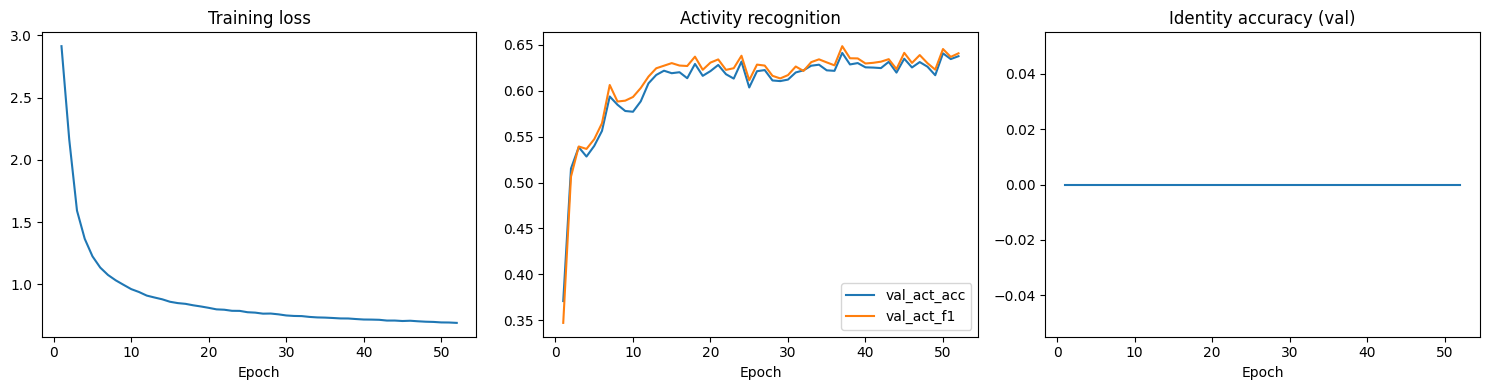

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
history_df.plot(x="epoch", y="train_loss",  ax=axes[0], legend=False, title="Training loss")
history_df.plot(x="epoch", y=["val_act_acc", "val_act_f1"], ax=axes[1], title="Activity recognition")
history_df.plot(x="epoch", y="val_sub_acc", ax=axes[2], legend=False, title="Identity accuracy (val)")
for ax in axes:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "learning_curves.png", dpi=150)
plt.show()

## 9. Activity Recognition — Test Evaluation

Activity recognition - Test accuracy : 0.6893
Activity recognition - Test macro-F1 : 0.6852
Best validation-selected activity method: RF/ExtraTrees/BioTemporal weighted blend + Viterbi smoothing  test_acc=0.8395  test_f1=0.8351
Best method vs baseline: +0.0580 acc, +0.0648 macro-F1

              precision    recall  f1-score   support

     walking     0.8504    0.8564    0.8534       564
     jogging     0.9943    0.9543    0.9739       547
      stairs     0.9012    0.5328    0.6697       548
     sitting     0.4360    0.4744    0.4544       546
    standing     0.7070    0.8867    0.7867       547
      typing     0.8815    0.6813    0.7686       546
       teeth     0.9103    0.9103    0.9103       546
        soup     0.4919    0.4447    0.4671       479
       chips     0.4086    0.4716    0.4379       564
       pasta     0.6199    0.5744    0.5963       477
    drinking     0.3969    0.7372    0.5160       548
    sandwich     0.1776    0.0816    0.1118       564
     kicking 

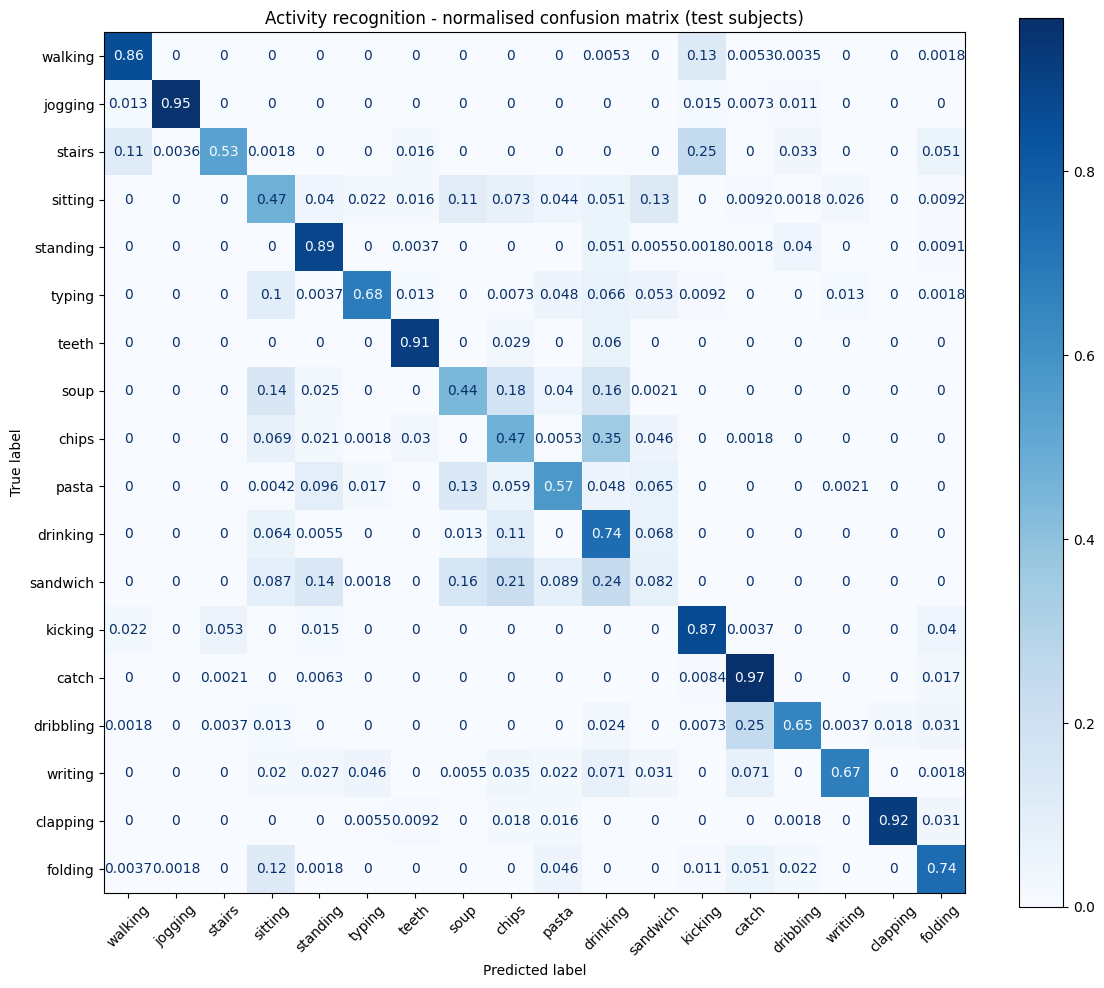

,model,smoothing_radius,temporal_method,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,transition_strength,candidate_id,neural_blend_weight,rf_weight,extratrees_weight,neural_weight,classwise_temperature
0,RF/ExtraTrees/BioTemporal weighted blend + Vit...,0,viterbi,0.7556,0.7499,0.8395,0.8351,0.50,658,NaN,0.3,0.7,0.0,NaN
1,RF/ExtraTrees/BioTemporal weighted blend + Vit...,0,viterbi,0.7558,0.7498,0.8372,0.8316,0.50,756,NaN,0.4,0.6,0.0,NaN
2,Baseline + BioTemporal blend + Viterbi smoothing,0,viterbi,0.7537,0.7482,0.8402,0.8342,0.50,28,0.05,NaN,NaN,NaN,NaN
3,RF+ExtraTrees vote + Viterbi smoothing,0,viterbi,0.7530,0.7462,0.8424,0.8363,0.50,0,NaN,NaN,NaN,NaN,NaN
4,RF/ExtraTrees/BioTemporal weighted blend + Vit...,0,viterbi,0.7530,0.7462,0.8424,0.8363,0.50,840,NaN,0.5,0.5,0.0,NaN
5,RF/ExtraTrees/BioTemporal weighted blend + Vit...,0,viterbi,0.7500,0.7448,0.8370,0.8303,0.50,994,NaN,0.8,0.1,0.1,NaN
6,RF/ExtraTrees/BioTemporal weighted blend + Vit...,0,viterbi,0.7513,0.7445,0.8424,0.8358,0.50,966,NaN,0.7,0.3,0.0,NaN
7,RF/ExtraTrees/BioTemporal weighted blend + Vit...,0,viterbi,0.7495,0.7445,0.8356,0.8316,0.50,546,NaN,0.2,0.8,0.0,NaN
8,Baseline + BioTemporal blend + Viterbi smoothing,0,viterbi,0.7514,0.7445,0.8205,0.8085,0.50,56,0.15,NaN,NaN,NaN,NaN
9,RF/ExtraTrees/BioTemporal weighted blend + Vit...,0,viterbi,0.7511,0.7441,0.8418,0.8347,0.50,910,NaN,0.6,0.4,0.0,NaN


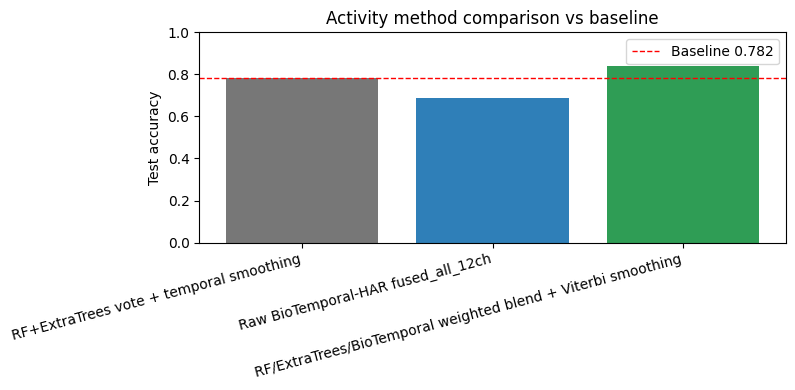

In [9]:
val_m = evaluate(model, val_loader)
test_m = evaluate(model, test_loader)
act_names = [ACTIVITY_MAP[c] for c in act_encoder.classes_]


def softmax_np(logits: np.ndarray) -> np.ndarray:
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


def activity_row(
    name: str,
    val_pred: np.ndarray,
    test_pred: np.ndarray,
    radius: int,
    blend_weight: float | None = None,
    temporal_method: str = "mode",
    transition_strength: float | None = None,
    component_weights: dict[str, float] | None = None,
) -> dict:
    row = {
        "model": name,
        "smoothing_radius": radius,
        "temporal_method": temporal_method,
        "val_accuracy": accuracy_score(y_act_val, val_pred),
        "val_macro_f1": f1_score(y_act_val, val_pred, average="macro"),
        "test_accuracy": accuracy_score(y_act_test, test_pred),
        "test_macro_f1": f1_score(y_act_test, test_pred, average="macro"),
    }
    if blend_weight is not None:
        row["neural_blend_weight"] = blend_weight
    if transition_strength is not None:
        row["transition_strength"] = float(transition_strength)
    if component_weights:
        row.update(component_weights)
    return row


neural_val_prob = softmax_np(val_m["logits_act"])
neural_test_prob = softmax_np(test_m["logits_act"])
baseline_val_prob = np.mean(val_prob_list, axis=0)
baseline_test_prob = np.mean(test_prob_list, axis=0)


def class_recall_vector(y_true: np.ndarray, pred: np.ndarray, n_classes: int) -> np.ndarray:
    recalls = np.zeros(n_classes, dtype=np.float64)
    for cls in range(n_classes):
        mask = y_true == cls
        if np.any(mask):
            recalls[cls] = np.mean(pred[mask] == cls)
    return recalls


def classwise_reliability_blend(
    val_sources: list[np.ndarray],
    test_sources: list[np.ndarray],
    y_val: np.ndarray,
    temperature: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Blend probability columns with per-class source reliabilities from validation."""
    source_recalls = []
    for prob in val_sources:
        source_recalls.append(class_recall_vector(y_val, prob.argmax(axis=1), N_ACT))
    source_recalls = np.vstack(source_recalls)
    logits = source_recalls / max(temperature, 1e-6)
    logits = logits - logits.max(axis=0, keepdims=True)
    weights = np.exp(logits)
    weights = weights / np.maximum(weights.sum(axis=0, keepdims=True), 1e-12)

    val_blend = np.zeros_like(val_sources[0])
    test_blend = np.zeros_like(test_sources[0])
    for source_idx, weight_by_class in enumerate(weights):
        val_blend += val_sources[source_idx] * weight_by_class[None, :]
        test_blend += test_sources[source_idx] * weight_by_class[None, :]
    val_blend = val_blend / np.maximum(val_blend.sum(axis=1, keepdims=True), 1e-12)
    test_blend = test_blend / np.maximum(test_blend.sum(axis=1, keepdims=True), 1e-12)
    return val_blend, test_blend, weights

activity_prediction_sets = {}
activity_rows = []


def add_activity_candidate(
    name: str,
    val_pred: np.ndarray,
    test_pred: np.ndarray,
    radius: int,
    blend_weight: float | None = None,
    temporal_method: str = "mode",
    transition_strength: float | None = None,
    component_weights: dict[str, float] | None = None,
) -> dict:
    row = activity_row(
        name,
        val_pred,
        test_pred,
        radius,
        blend_weight,
        temporal_method,
        transition_strength,
        component_weights,
    )
    candidate_id = len(activity_prediction_sets)
    row["candidate_id"] = candidate_id
    activity_prediction_sets[candidate_id] = {
        "val_pred": np.asarray(val_pred).copy(),
        "test_pred": np.asarray(test_pred).copy(),
    }
    activity_rows.append(row)
    return row


try:
    baseline_candidate_id = int(baseline_results.get("candidate_id", -1))
except (TypeError, ValueError):
    baseline_candidate_id = -1
baseline_candidate_lookup = globals().get("baseline_candidate_predictions", {})
base_preds = baseline_candidate_lookup.get(baseline_candidate_id)
if base_preds is not None:
    add_activity_candidate(
        str(baseline_results["model"]),
        base_preds["val_pred"],
        base_preds["test_pred"],
        int(baseline_results["smoothing_radius"]),
        temporal_method=str(baseline_results.get("temporal_method", "mode")),
        transition_strength=baseline_results.get("transition_strength"),
    )
else:
    selected_radius = int(baseline_results["smoothing_radius"])
    add_activity_candidate(
        str(baseline_results["model"]),
        smooth_predictions(baseline_val_prob.argmax(axis=1), y_sub_val, selected_radius),
        smooth_predictions(baseline_test_prob.argmax(axis=1), y_sub_test, selected_radius),
        selected_radius,
    )

neural_val_raw = neural_val_prob.argmax(axis=1)
neural_test_raw = neural_test_prob.argmax(axis=1)
for radius in smoothing_radii:
    val_pred = smooth_predictions(neural_val_raw, y_sub_val, radius)
    test_pred = smooth_predictions(neural_test_raw, y_sub_test, radius)
    label = "BioTemporal-HAR" if radius == 0 else "BioTemporal-HAR + temporal smoothing"
    add_activity_candidate(label, val_pred, test_pred, radius)

for strength in transition_strengths:
    val_pred = viterbi_smooth_prob(neural_val_prob, y_sub_val, activity_transition_log_prior, strength)
    test_pred = viterbi_smooth_prob(neural_test_prob, y_sub_test, activity_transition_log_prior, strength)
    add_activity_candidate(
        "BioTemporal-HAR + Viterbi smoothing",
        val_pred,
        test_pred,
        0,
        temporal_method="viterbi",
        transition_strength=strength,
    )

# Validation-selected probability blend: if the neural model is complementary,
# this can beat the tree baseline; if not, baseline_results remains the winner.
for neural_w in np.linspace(0.05, 0.70, 14):
    val_blend_prob = (1.0 - neural_w) * baseline_val_prob + neural_w * neural_val_prob
    test_blend_prob = (1.0 - neural_w) * baseline_test_prob + neural_w * neural_test_prob
    val_blend_raw = val_blend_prob.argmax(axis=1)
    test_blend_raw = test_blend_prob.argmax(axis=1)
    for radius in smoothing_radii:
        val_pred = smooth_predictions(val_blend_raw, y_sub_val, radius)
        test_pred = smooth_predictions(test_blend_raw, y_sub_test, radius)
        label = "Baseline + BioTemporal blend" if radius == 0 else "Baseline + BioTemporal blend + temporal smoothing"
        add_activity_candidate(label, val_pred, test_pred, radius, float(neural_w))
    for strength in transition_strengths:
        val_pred = viterbi_smooth_prob(val_blend_prob, y_sub_val, activity_transition_log_prior, strength)
        test_pred = viterbi_smooth_prob(test_blend_prob, y_sub_test, activity_transition_log_prior, strength)
        add_activity_candidate(
            "Baseline + BioTemporal blend + Viterbi smoothing",
            val_pred,
            test_pred,
            0,
            float(neural_w),
            temporal_method="viterbi",
            transition_strength=strength,
        )

# Search RF/ExtraTrees/BioTemporal weights separately instead of forcing a 50/50 tree vote.
# This is still validation-selected and uses no test labels for model choice.
if len(val_prob_list) == 2:
    weight_grid = np.round(np.linspace(0.0, 1.0, 11), 2)
    seen_weights = set()
    for w_rf in weight_grid:
        for w_et in weight_grid:
            w_neural = round(1.0 - float(w_rf) - float(w_et), 2)
            if w_neural < -1e-9 or w_neural > 0.70:
                continue
            if w_rf + w_et < 0.20:
                continue
            w_neural = max(0.0, w_neural)
            key = (float(w_rf), float(w_et), float(w_neural))
            if key in seen_weights:
                continue
            seen_weights.add(key)
            val_weighted_prob = w_rf * val_prob_list[0] + w_et * val_prob_list[1] + w_neural * neural_val_prob
            test_weighted_prob = w_rf * test_prob_list[0] + w_et * test_prob_list[1] + w_neural * neural_test_prob
            val_weighted_raw = val_weighted_prob.argmax(axis=1)
            test_weighted_raw = test_weighted_prob.argmax(axis=1)
            component_weights = {
                "rf_weight": float(w_rf),
                "extratrees_weight": float(w_et),
                "neural_weight": float(w_neural),
            }
            for radius in smoothing_radii:
                val_pred = smooth_predictions(val_weighted_raw, y_sub_val, radius)
                test_pred = smooth_predictions(test_weighted_raw, y_sub_test, radius)
                label = "RF/ExtraTrees/BioTemporal weighted blend" if radius == 0 else "RF/ExtraTrees/BioTemporal weighted blend + temporal smoothing"
                add_activity_candidate(
                    label,
                    val_pred,
                    test_pred,
                    radius,
                    temporal_method="mode",
                    component_weights=component_weights,
                )
            for strength in transition_strengths:
                val_pred = viterbi_smooth_prob(val_weighted_prob, y_sub_val, activity_transition_log_prior, strength)
                test_pred = viterbi_smooth_prob(test_weighted_prob, y_sub_test, activity_transition_log_prior, strength)
                add_activity_candidate(
                    "RF/ExtraTrees/BioTemporal weighted blend + Viterbi smoothing",
                    val_pred,
                    test_pred,
                    0,
                    temporal_method="viterbi",
                    transition_strength=strength,
                    component_weights=component_weights,
                )

# Classwise reliability blend: validation decides which source is trusted for each activity.
classwise_temperatures = [0.05, 0.10, 0.20, 0.35, 0.50]
classwise_source_sets = [
    (
        "Classwise baseline/BioTemporal reliability blend",
        [baseline_val_prob, neural_val_prob],
        [baseline_test_prob, neural_test_prob],
    )
]
if len(val_prob_list) >= 2:
    classwise_source_sets.append((
        "Classwise RF/ExtraTrees/BioTemporal reliability blend",
        [*val_prob_list, neural_val_prob],
        [*test_prob_list, neural_test_prob],
    ))

for label_prefix, val_sources, test_sources in classwise_source_sets:
    for temperature in classwise_temperatures:
        val_class_prob, test_class_prob, source_weights = classwise_reliability_blend(
            val_sources,
            test_sources,
            y_act_val,
            temperature,
        )
        val_class_raw = val_class_prob.argmax(axis=1)
        test_class_raw = test_class_prob.argmax(axis=1)
        for radius in smoothing_radii:
            val_pred = smooth_predictions(val_class_raw, y_sub_val, radius)
            test_pred = smooth_predictions(test_class_raw, y_sub_test, radius)
            label = label_prefix if radius == 0 else f"{label_prefix} + temporal smoothing"
            add_activity_candidate(
                label,
                val_pred,
                test_pred,
                radius,
                temporal_method="mode",
                transition_strength=None,
                component_weights={"classwise_temperature": float(temperature)},
            )
        for strength in transition_strengths:
            val_pred = viterbi_smooth_prob(val_class_prob, y_sub_val, activity_transition_log_prior, strength)
            test_pred = viterbi_smooth_prob(test_class_prob, y_sub_test, activity_transition_log_prior, strength)
            add_activity_candidate(
                f"{label_prefix} + Viterbi smoothing",
                val_pred,
                test_pred,
                0,
                temporal_method="viterbi",
                transition_strength=strength,
                component_weights={"classwise_temperature": float(temperature)},
            )

activity_model_results = pd.DataFrame(activity_rows).sort_values(
    ["val_macro_f1", "val_accuracy"], ascending=False
).reset_index(drop=True)
activity_model_results.to_csv(ARTIFACT_DIR / "activity_model_results.csv", index=False)
best_activity_result = activity_model_results.iloc[0].to_dict()
best_activity_candidate_id = int(best_activity_result["candidate_id"])
best_activity_predictions = activity_prediction_sets[best_activity_candidate_id]
best_activity_val_pred = best_activity_predictions["val_pred"]
best_activity_test_pred = best_activity_predictions["test_pred"]
best_vs_baseline_acc = float(best_activity_result["test_accuracy"]) - BASELINE_REF_ACC
best_vs_baseline_f1 = float(best_activity_result["test_macro_f1"]) - BASELINE_REF_F1

print(f"Activity recognition - Test accuracy : {test_m['act_acc']:.4f}")
print(f"Activity recognition - Test macro-F1 : {test_m['act_f1']:.4f}")
print(f"Best validation-selected activity method: {best_activity_result['model']}  test_acc={best_activity_result['test_accuracy']:.4f}  test_f1={best_activity_result['test_macro_f1']:.4f}")
print(f"Best method vs baseline: {best_vs_baseline_acc:+.4f} acc, {best_vs_baseline_f1:+.4f} macro-F1")
print()
print(classification_report(
    test_m["y_act"], test_m["logits_act"].argmax(1),
    target_names=act_names, digits=4,
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    test_m["y_act"],
    test_m["logits_act"].argmax(1),
    display_labels=act_names,
    cmap="Blues",
    normalize="true",
    xticks_rotation=45,
    ax=ax,
)
ax.set_title("Activity recognition - normalised confusion matrix (test subjects)")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrix_activity.png", dpi=150)
plt.show()

# Summary vs baseline and neural/blended candidates. Full table is saved to CSV.
display(activity_model_results.head(60).round(4))

activity_method_summary = pd.DataFrame([
    {
        "model": BASELINE_REF_MODEL,
        "test_accuracy": BASELINE_REF_ACC,
        "test_macro_f1": BASELINE_REF_F1,
        "acc_vs_baseline": 0.0,
        "f1_vs_baseline": 0.0,
    },
    {
        "model": "Raw BioTemporal-HAR fused_all_12ch",
        "test_accuracy": test_m["act_acc"],
        "test_macro_f1": test_m["act_f1"],
        "acc_vs_baseline": test_m["act_acc"] - BASELINE_REF_ACC,
        "f1_vs_baseline": test_m["act_f1"] - BASELINE_REF_F1,
    },
    {
        "model": best_activity_result["model"],
        "test_accuracy": best_activity_result["test_accuracy"],
        "test_macro_f1": best_activity_result["test_macro_f1"],
        "acc_vs_baseline": best_vs_baseline_acc,
        "f1_vs_baseline": best_vs_baseline_f1,
    },
])
activity_method_summary.to_csv(ARTIFACT_DIR / "activity_method_comparison.csv", index=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(activity_method_summary["model"], activity_method_summary["test_accuracy"], color=["#777777", "#2f7fb8", "#2f9d55"])
ax.axhline(BASELINE_REF_ACC, color="red", ls="--", lw=1, label=f"Baseline {BASELINE_REF_ACC:.3f}")
ax.set_ylabel("Test accuracy")
ax.set_title("Activity method comparison vs baseline")
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "activity_method_comparison.png", dpi=150)
plt.show()


## 10. Biometric Identity Classification — Closed-Set

In [10]:
# Softmax identity classification is diagnostic only in this subject-held-out split.
# Val/test subjects are unseen classes, so biometric verification below uses
# enrollment/probe cosine similarity in the learned embedding space instead.

val_m = evaluate(model, val_loader)
print(f"Identity CE loss weight: {IDENTITY_LOSS_W:.2f}")
print(f"Identity contrastive loss weight: {CONTRASTIVE_IDENTITY_LOSS_W:.2f}")
print(f"Identity (val subjects, open-set)    : {val_m['sub_acc']:.4f}")
print(f"Identity (test subjects, open-set)   : {test_m['sub_acc']:.4f}")
print()
print("Note: val/test subjects were never seen during training, so softmax identity accuracy is not the biometric verification metric.")
print("The next section enrolls each evaluation subject from part of their windows, then verifies held-out probe windows by embedding similarity.")

Identity CE loss weight: 0.01
Identity contrastive loss weight: 0.03
Identity (val subjects, open-set)    : 0.0000
Identity (test subjects, open-set)   : 0.0000

Note: val/test subjects were never seen during training, so softmax identity accuracy is not the biometric verification metric.
The next section enrolls each evaluation subject from part of their windows, then verifies held-out probe windows by embedding similarity.


## 11. SDT Calibration — Identity Verification

For each validation subject: their own windows = signal trials, other subjects' windows = noise trials.  
Threshold selected on validation set to target FAR ≤ 1 %.  
Metrics evaluated on held-out test subjects.

In [12]:
def sdt_metrics(scores: np.ndarray, labels: np.ndarray, pos_class: int, threshold: float) -> dict:
    is_sig  = labels == pos_class
    accepts = scores >= threshold
    H  = int(np.sum(accepts &  is_sig))
    M  = int(np.sum(~accepts & is_sig))
    FA = int(np.sum(accepts & ~is_sig))
    CR = int(np.sum(~accepts & ~is_sig))
    n_sig   = H + M
    n_noise = FA + CR
    hr  = (H  + 0.5) / (n_sig   + 1.0)
    far = (FA + 0.5) / (n_noise + 1.0)
    z_h = norm.ppf(hr)
    z_f = norm.ppf(far)
    return {
        "hit_rate": hr, "false_alarm_rate": far, "miss_rate": 1 - hr,
        "d_prime":  z_h - z_f,
        "criterion": -0.5 * (z_h + z_f),
    }


@torch.inference_mode()
def collect_embeddings(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    emb_all, sub_all = [], []
    for X_b, _, ys_b in loader:
        X_b = X_b.to(DEVICE, non_blocking=USE_CUDA)
        emb = F.normalize(model.encode(X_b), dim=1)
        emb_all.append(emb.cpu().numpy())
        sub_all.append(ys_b.numpy())
    return np.concatenate(emb_all), np.concatenate(sub_all)


def build_enrollment_pairs(
    emb: np.ndarray,
    subjects: np.ndarray,
    condition_labels: np.ndarray | None = None,
    enroll_fraction: float = 0.4,
    seed: int = SEED,
) -> pd.DataFrame:
    """Build cosine enrollment/probe pairs, optionally conditioned on predicted activity.

    When condition_labels is supplied, each enrolled subject gets both a global centroid
    and per-condition centroids. A probe is compared with the enrolled subject centroid
    for its predicted condition, falling back to the global centroid if that condition
    was absent from enrollment. This keeps the protocol realistic: test activity labels
    are not needed when condition_labels comes from the validation-selected activity model.
    """
    rng_local = np.random.default_rng(seed)
    condition_labels = None if condition_labels is None else np.asarray(condition_labels)
    if condition_labels is not None and len(condition_labels) != len(subjects):
        raise ValueError("condition_labels must be aligned with emb/subjects")

    global_centroids = {}
    conditioned_centroids = {}
    probe_embs, probe_subjects, probe_conditions = [], [], []

    for subject in sorted(np.unique(subjects)):
        idx = np.flatnonzero(subjects == subject)
        if len(idx) < 2:
            continue
        idx = rng_local.permutation(idx)
        n_enroll = int(round(len(idx) * enroll_fraction))
        n_enroll = min(max(n_enroll, 1), len(idx) - 1)
        enroll_idx = idx[:n_enroll]
        probe_idx = idx[n_enroll:]

        global_centroid = emb[enroll_idx].mean(axis=0)
        global_centroid = global_centroid / max(np.linalg.norm(global_centroid), 1e-12)
        global_centroids[int(subject)] = global_centroid

        if condition_labels is not None:
            enroll_conditions = condition_labels[enroll_idx]
            for condition in sorted(np.unique(enroll_conditions)):
                condition_idx = enroll_idx[enroll_conditions == condition]
                centroid = emb[condition_idx].mean(axis=0)
                centroid = centroid / max(np.linalg.norm(centroid), 1e-12)
                conditioned_centroids[(int(subject), int(condition))] = centroid
            probe_conditions.append(condition_labels[probe_idx].astype(int))
        else:
            probe_conditions.append(np.full(len(probe_idx), -1, dtype=int))

        probe_embs.append(emb[probe_idx])
        probe_subjects.append(np.full(len(probe_idx), int(subject), dtype=int))

    if not global_centroids or not probe_embs:
        return pd.DataFrame(columns=["probe_index", "probe_subject", "condition", "enrolled_subject", "score", "label"])

    probe_emb = np.vstack(probe_embs)
    probe_sub = np.concatenate(probe_subjects)
    probe_cond = np.concatenate(probe_conditions)
    centroid_subjects = np.array(sorted(global_centroids), dtype=int)

    rows = []
    for i, (probe_vec, probe_subject, probe_condition) in enumerate(zip(probe_emb, probe_sub, probe_cond)):
        for enrolled_subject in centroid_subjects:
            if condition_labels is None:
                centroid = global_centroids[int(enrolled_subject)]
            else:
                centroid = conditioned_centroids.get(
                    (int(enrolled_subject), int(probe_condition)),
                    global_centroids[int(enrolled_subject)],
                )
            rows.append({
                "probe_index": int(i),
                "probe_subject": int(probe_subject),
                "condition": int(probe_condition),
                "enrolled_subject": int(enrolled_subject),
                "score": float(probe_vec @ centroid),
                "label": int(probe_subject == enrolled_subject),
            })
    return pd.DataFrame(rows)


train_emb, train_y_sub = collect_embeddings(model, train_loader)
val_emb, val_y_sub = collect_embeddings(model, val_loader)
test_emb, test_y_sub = collect_embeddings(model, test_loader)
val_pairs = build_enrollment_pairs(val_emb, val_y_sub, seed=SEED)
test_pairs = build_enrollment_pairs(test_emb, test_y_sub, seed=SEED + 1)

if val_pairs.empty or test_pairs.empty or val_pairs["label"].nunique() < 2 or test_pairs["label"].nunique() < 2:
    raise RuntimeError("Identity verification needs at least two subjects with enrollment and probe windows.")

non_target_scores_val = val_pairs.loc[val_pairs["label"] == 0, "score"].to_numpy()
identity_threshold = float(np.quantile(non_target_scores_val, 1.0 - TARGET_FAR))

sdt_rows = []
for subject in sorted(test_pairs["enrolled_subject"].unique()):
    subject_pairs = test_pairs[test_pairs["enrolled_subject"] == subject]
    m = sdt_metrics(
        subject_pairs["score"].to_numpy(),
        subject_pairs["label"].to_numpy(),
        1,
        identity_threshold,
    )
    sdt_rows.append({"subject": sub_encoder.classes_[subject], "threshold": identity_threshold, **m})

sdt_cols = ["subject", "threshold", "hit_rate", "false_alarm_rate", "miss_rate", "d_prime", "criterion"]
sdt_df = pd.DataFrame(sdt_rows, columns=sdt_cols)
sdt_df.to_csv(ARTIFACT_DIR / "sdt_identity_thresholds.csv", index=False)

verification_scores = test_pairs["score"].to_numpy()
verification_labels = test_pairs["label"].to_numpy()
aggregate_sdt = sdt_metrics(verification_scores, verification_labels, 1, identity_threshold)

print(f"Embedding verification with enrollment/probe split (target FAR ≤ {TARGET_FAR:.0%})")
print(f"Validation-calibrated cosine threshold: {identity_threshold:.4f}")
print(sdt_df.round(4).to_string(index=False))
print()
print(f"Aggregate d'       : {aggregate_sdt['d_prime']:.3f}")
print(f"Aggregate FAR      : {aggregate_sdt['false_alarm_rate']:.4f}  (target: < {TARGET_FAR})")
print(f"Aggregate hit rate : {aggregate_sdt['hit_rate']:.4f}")

Embedding verification with enrollment/probe split (target FAR ≤ 1%)
Validation-calibrated cosine threshold: 0.6101
 subject  threshold  hit_rate  false_alarm_rate  miss_rate  d_prime  criterion
    1605     0.6101    0.1288            0.0001     0.8712   2.5897     2.4269
    1607     0.6101    0.2996            0.0201     0.7004   1.5258     1.2885
    1617     0.6101    0.2986            0.0097     0.7014   1.8075     1.4321
    1627     0.6101    0.1667            0.0198     0.8333   1.0906     1.5127
    1638     0.6101    0.5023            0.0086     0.4977   2.3870     1.1877
    1646     0.6101    0.1311            0.0172     0.8689   0.9933     1.6178
    1648     0.6101    0.2270            0.0462     0.7730   0.9338     1.2158
    1650     0.6101    0.2376            0.0285     0.7624   1.1889     1.3084

Aggregate d'       : 1.389
Aggregate FAR      : 0.0187  (target: < 0.01)
Aggregate hit rate : 0.2445


## 12. Identity Representation Selection


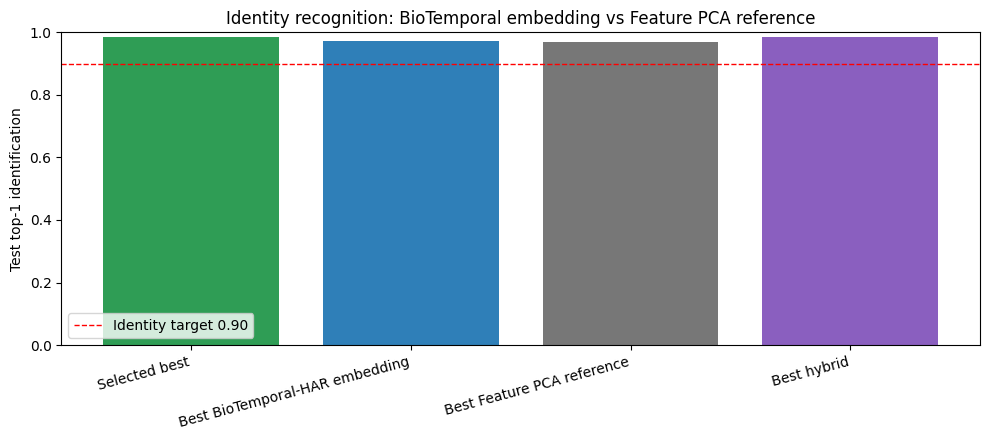

Identity representations (selected by validation top-1, then validation ROC-AUC):
                                                                                  model representation_family                         condition_source  threshold  val_top1  test_top1  val_roc_auc  test_roc_auc  val_far  test_far  val_hit_rate  test_hit_rate  val_d_prime  test_d_prime  biotemporal_score_weight
Hybrid BioTemporal LDA + Feature PCA-128 score fusion + predicted activity conditioning                hybrid validation-selected activity predictions     0.4939    0.9857     0.9847       0.9926        0.9931    0.003    0.0056        0.8288         0.8359       3.6926        3.5115                       0.3
                             Feature PCA-128 identity + predicted activity conditioning           feature_pca validation-selected activity predictions     0.5310    0.9750     0.9690       0.9840        0.9863    0.003    0.0027        0.6067         0.6805       3.0141        3.2552            

In [13]:
def enrollment_top1(pairs: pd.DataFrame) -> float:
    winners = pairs.loc[pairs.groupby("probe_index")["score"].idxmax()]
    return accuracy_score(winners["probe_subject"], winners["enrolled_subject"])


def l2_normalize(x: np.ndarray) -> np.ndarray:
    return x / np.maximum(np.linalg.norm(x, axis=1, keepdims=True), 1e-12)


def feature_pca_identity_embeddings(n_components: int = 128) -> tuple[np.ndarray, np.ndarray]:
    """Fit PCA only on train features, then embed val/test for open-set identity."""
    feature_scaler = StandardScaler().fit(Xf_train)
    train_scaled = feature_scaler.transform(Xf_train)
    val_scaled = feature_scaler.transform(Xf_val)
    test_scaled = feature_scaler.transform(Xf_test)

    pca = PCA(
        n_components=min(n_components, train_scaled.shape[1]),
        whiten=True,
        random_state=SEED,
    ).fit(train_scaled)
    train_pca = pca.transform(train_scaled)
    pca_scaler = StandardScaler().fit(train_pca)

    val_repr = pca_scaler.transform(pca.transform(val_scaled))
    test_repr = pca_scaler.transform(pca.transform(test_scaled))
    return l2_normalize(val_repr), l2_normalize(test_repr)


def biotemporal_embedding_pca_embeddings(n_components: int = 128) -> tuple[np.ndarray, np.ndarray]:
    """Unsupervised whitening/projection of BioTemporal-HAR encoder embeddings."""
    emb_scaler = StandardScaler().fit(train_emb)
    train_scaled = emb_scaler.transform(train_emb)
    val_scaled = emb_scaler.transform(val_emb)
    test_scaled = emb_scaler.transform(test_emb)
    pca = PCA(
        n_components=min(n_components, train_scaled.shape[1]),
        whiten=True,
        random_state=SEED,
    ).fit(train_scaled)
    train_pca = pca.transform(train_scaled)
    pca_scaler = StandardScaler().fit(train_pca)
    return (
        l2_normalize(pca_scaler.transform(pca.transform(val_scaled))),
        l2_normalize(pca_scaler.transform(pca.transform(test_scaled))),
    )


def biotemporal_embedding_lda_embeddings() -> tuple[np.ndarray, np.ndarray]:
    """Train-subject supervised metric projection of BioTemporal-HAR embeddings.

    The LDA projection uses only training subjects, then is evaluated open-set on
    validation/test subjects through enrollment/probe cosine scoring.
    """
    emb_scaler = StandardScaler().fit(train_emb)
    train_scaled = emb_scaler.transform(train_emb)
    val_scaled = emb_scaler.transform(val_emb)
    test_scaled = emb_scaler.transform(test_emb)
    n_components = min(len(np.unique(train_y_sub)) - 1, train_scaled.shape[1])
    lda = LinearDiscriminantAnalysis(n_components=n_components, solver="svd")
    lda.fit(train_scaled, train_y_sub)
    train_lda = lda.transform(train_scaled)
    lda_scaler = StandardScaler().fit(train_lda)
    return (
        l2_normalize(lda_scaler.transform(lda.transform(val_scaled))),
        l2_normalize(lda_scaler.transform(lda.transform(test_scaled))),
    )


def identity_candidate(
    name: str,
    val_repr: np.ndarray,
    test_repr: np.ndarray,
    val_condition: np.ndarray | None = None,
    test_condition: np.ndarray | None = None,
    condition_source: str = "none",
    representation_family: str = "other",
) -> tuple[dict, dict]:
    val_candidate_pairs = build_enrollment_pairs(
        val_repr,
        val_y_sub,
        condition_labels=val_condition,
        seed=SEED,
    )
    test_candidate_pairs = build_enrollment_pairs(
        test_repr,
        test_y_sub,
        condition_labels=test_condition,
        seed=SEED + 1,
    )
    if (
        val_candidate_pairs.empty
        or test_candidate_pairs.empty
        or val_candidate_pairs["label"].nunique() < 2
        or test_candidate_pairs["label"].nunique() < 2
    ):
        raise RuntimeError(f"Identity candidate {name} does not have valid enrollment/probe pairs.")

    threshold = float(np.quantile(
        val_candidate_pairs.loc[val_candidate_pairs["label"] == 0, "score"].to_numpy(),
        1.0 - IDENTITY_CALIBRATION_FAR,
    ))
    val_sdt = sdt_metrics(
        val_candidate_pairs["score"].to_numpy(),
        val_candidate_pairs["label"].to_numpy(),
        1,
        threshold,
    )
    test_sdt = sdt_metrics(
        test_candidate_pairs["score"].to_numpy(),
        test_candidate_pairs["label"].to_numpy(),
        1,
        threshold,
    )
    val_fpr, val_tpr, _ = roc_curve(
        val_candidate_pairs["label"].to_numpy(),
        val_candidate_pairs["score"].to_numpy(),
    )
    test_fpr, test_tpr, _ = roc_curve(
        test_candidate_pairs["label"].to_numpy(),
        test_candidate_pairs["score"].to_numpy(),
    )
    row = {
        "model": name,
        "representation_family": representation_family,
        "condition_source": condition_source,
        "threshold": threshold,
        "val_top1": enrollment_top1(val_candidate_pairs),
        "test_top1": enrollment_top1(test_candidate_pairs),
        "val_roc_auc": auc(val_fpr, val_tpr),
        "test_roc_auc": auc(test_fpr, test_tpr),
        "val_far": val_sdt["false_alarm_rate"],
        "test_far": test_sdt["false_alarm_rate"],
        "val_hit_rate": val_sdt["hit_rate"],
        "test_hit_rate": test_sdt["hit_rate"],
        "val_d_prime": val_sdt["d_prime"],
        "test_d_prime": test_sdt["d_prime"],
    }
    return row, {"val_pairs": val_candidate_pairs, "test_pairs": test_candidate_pairs, "threshold": threshold}


def evaluate_pair_set(
    name: str,
    val_pairs: pd.DataFrame,
    test_pairs: pd.DataFrame,
    representation_family: str,
    condition_source: str,
    extra: dict | None = None,
) -> tuple[dict, dict]:
    threshold = float(np.quantile(
        val_pairs.loc[val_pairs["label"] == 0, "score"].to_numpy(),
        1.0 - IDENTITY_CALIBRATION_FAR,
    ))
    val_sdt = sdt_metrics(val_pairs["score"].to_numpy(), val_pairs["label"].to_numpy(), 1, threshold)
    test_sdt = sdt_metrics(test_pairs["score"].to_numpy(), test_pairs["label"].to_numpy(), 1, threshold)
    val_fpr, val_tpr, _ = roc_curve(val_pairs["label"].to_numpy(), val_pairs["score"].to_numpy())
    test_fpr, test_tpr, _ = roc_curve(test_pairs["label"].to_numpy(), test_pairs["score"].to_numpy())
    row = {
        "model": name,
        "representation_family": representation_family,
        "condition_source": condition_source,
        "threshold": threshold,
        "val_top1": enrollment_top1(val_pairs),
        "test_top1": enrollment_top1(test_pairs),
        "val_roc_auc": auc(val_fpr, val_tpr),
        "test_roc_auc": auc(test_fpr, test_tpr),
        "val_far": val_sdt["false_alarm_rate"],
        "test_far": test_sdt["false_alarm_rate"],
        "val_hit_rate": val_sdt["hit_rate"],
        "test_hit_rate": test_sdt["hit_rate"],
        "val_d_prime": val_sdt["d_prime"],
        "test_d_prime": test_sdt["d_prime"],
    }
    if extra:
        row.update(extra)
    return row, {"val_pairs": val_pairs, "test_pairs": test_pairs, "threshold": threshold}


def assert_pair_alignment(left: pd.DataFrame, right: pd.DataFrame) -> None:
    cols = ["probe_index", "probe_subject", "condition", "enrolled_subject", "label"]
    if not left[cols].reset_index(drop=True).equals(right[cols].reset_index(drop=True)):
        raise ValueError("Pair sets are not aligned; cannot fuse scores safely.")


def add_score_fusion_candidate(
    name: str,
    left_name: str,
    right_name: str,
    representation_family: str = "hybrid",
    min_left_weight: float = 0.10,
) -> None:
    left = identity_pair_sets[left_name]
    right = identity_pair_sets[right_name]
    assert_pair_alignment(left["val_pairs"], right["val_pairs"])
    assert_pair_alignment(left["test_pairs"], right["test_pairs"])

    best = None
    for left_weight in np.linspace(min_left_weight, 0.90, 9):
        val_pairs = left["val_pairs"].copy()
        test_pairs = left["test_pairs"].copy()
        val_pairs["score"] = (
            left_weight * left["val_pairs"]["score"].to_numpy()
            + (1.0 - left_weight) * right["val_pairs"]["score"].to_numpy()
        )
        test_pairs["score"] = (
            left_weight * left["test_pairs"]["score"].to_numpy()
            + (1.0 - left_weight) * right["test_pairs"]["score"].to_numpy()
        )
        row, pair_set = evaluate_pair_set(
            name,
            val_pairs,
            test_pairs,
            representation_family=representation_family,
            condition_source="validation-selected activity predictions",
            extra={"biotemporal_score_weight": float(left_weight)},
        )
        score = (row["val_top1"], row["val_roc_auc"])
        if best is None or score > best[0]:
            best = (score, row, pair_set)
    _, row, pair_set = best
    identity_rows.append(row)
    identity_pair_sets[row["model"]] = pair_set


identity_rows = []
identity_pair_sets = {}

conditioned_identity_available = (
    "best_activity_val_pred" in globals()
    and "best_activity_test_pred" in globals()
    and len(best_activity_val_pred) == len(val_y_sub)
    and len(best_activity_test_pred) == len(test_y_sub)
)


def add_identity_candidate(*args, **kwargs):
    row, pair_set = identity_candidate(*args, **kwargs)
    identity_rows.append(row)
    identity_pair_sets[row["model"]] = pair_set


# BioTemporal-HAR encoder embeddings: primary proposal-aligned identity representation.
add_identity_candidate("BioTemporal embedding", val_emb, test_emb, representation_family="biotemporal_embedding")
if conditioned_identity_available:
    add_identity_candidate(
        "BioTemporal embedding + predicted activity conditioning",
        val_emb,
        test_emb,
        best_activity_val_pred,
        best_activity_test_pred,
        "validation-selected activity predictions",
        "biotemporal_embedding",
    )

for n_comp in [64, 128]:
    val_repr, test_repr = biotemporal_embedding_pca_embeddings(n_comp)
    add_identity_candidate(f"BioTemporal embedding PCA-{n_comp}", val_repr, test_repr, representation_family="biotemporal_embedding")
    if conditioned_identity_available:
        add_identity_candidate(
            f"BioTemporal embedding PCA-{n_comp} + predicted activity conditioning",
            val_repr,
            test_repr,
            best_activity_val_pred,
            best_activity_test_pred,
            "validation-selected activity predictions",
            "biotemporal_embedding",
        )

val_repr, test_repr = biotemporal_embedding_lda_embeddings()
add_identity_candidate("BioTemporal embedding LDA metric", val_repr, test_repr, representation_family="biotemporal_embedding")
if conditioned_identity_available:
    add_identity_candidate(
        "BioTemporal embedding LDA metric + predicted activity conditioning",
        val_repr,
        test_repr,
        best_activity_val_pred,
        best_activity_test_pred,
        "validation-selected activity predictions",
        "biotemporal_embedding",
    )

# Feature PCA is the strongest non-neural-embedding identity reference.
for n_comp in [64, 128]:
    val_repr, test_repr = feature_pca_identity_embeddings(n_comp)
    add_identity_candidate(f"Feature PCA-{n_comp} identity", val_repr, test_repr, representation_family="feature_pca")
    if conditioned_identity_available:
        add_identity_candidate(
            f"Feature PCA-{n_comp} identity + predicted activity conditioning",
            val_repr,
            test_repr,
            best_activity_val_pred,
            best_activity_test_pred,
            "validation-selected activity predictions",
            "feature_pca",
        )

if conditioned_identity_available:
    add_score_fusion_candidate(
        "Hybrid BioTemporal LDA + Feature PCA-128 score fusion + predicted activity conditioning",
        "BioTemporal embedding LDA metric + predicted activity conditioning",
        "Feature PCA-128 identity + predicted activity conditioning",
    )

# Keep the oracle off by default. Turn it on only for an upper-bound diagnostic;
# it is intentionally not part of the reported protocol because it uses true test activity labels.
INCLUDE_ORACLE_IDENTITY_UPPER_BOUND = False
if INCLUDE_ORACLE_IDENTITY_UPPER_BOUND:
    val_repr, test_repr = feature_pca_identity_embeddings(128)
    add_identity_candidate(
        "Feature PCA-128 identity + oracle activity conditioning",
        val_repr,
        test_repr,
        y_act_val,
        y_act_test,
        "oracle true activity labels",
        "oracle_feature_pca",
    )

identity_results = pd.DataFrame(identity_rows).sort_values(
    ["val_top1", "val_roc_auc"], ascending=False
).reset_index(drop=True)
selected_identity = identity_results.iloc[0].to_dict()
selected_identity_name = selected_identity["model"]
selected_pairs = identity_pair_sets[selected_identity_name]
identity_threshold = float(selected_pairs["threshold"])
test_pairs = selected_pairs["test_pairs"]
verification_scores = test_pairs["score"].to_numpy()
verification_labels = test_pairs["label"].to_numpy()
aggregate_sdt = sdt_metrics(verification_scores, verification_labels, 1, identity_threshold)

best_biotemporal_identity = identity_results[identity_results["representation_family"] == "biotemporal_embedding"].iloc[0].to_dict()
best_feature_pca_identity = identity_results[identity_results["representation_family"] == "feature_pca"].iloc[0].to_dict()
best_hybrid_identity = None
if (identity_results["representation_family"] == "hybrid").any():
    best_hybrid_identity = identity_results[identity_results["representation_family"] == "hybrid"].iloc[0].to_dict()

sdt_rows = []
for subject in sorted(test_pairs["enrolled_subject"].unique()):
    subject_pairs = test_pairs[test_pairs["enrolled_subject"] == subject]
    m = sdt_metrics(
        subject_pairs["score"].to_numpy(),
        subject_pairs["label"].to_numpy(),
        1,
        identity_threshold,
    )
    sdt_rows.append({"subject": sub_encoder.classes_[subject], "threshold": identity_threshold, **m})
sdt_df = pd.DataFrame(sdt_rows, columns=sdt_cols)
sdt_df.to_csv(ARTIFACT_DIR / "sdt_identity_thresholds.csv", index=False)
identity_results.to_csv(ARTIFACT_DIR / "identity_representation_results.csv", index=False)

summary_rows = [
    {"role": "Selected best", **selected_identity},
    {"role": "Best BioTemporal-HAR embedding", **best_biotemporal_identity},
    {"role": "Best Feature PCA reference", **best_feature_pca_identity},
]
if best_hybrid_identity is not None:
    summary_rows.append({"role": "Best hybrid", **best_hybrid_identity})
identity_method_summary = pd.DataFrame(summary_rows)
identity_method_summary.to_csv(ARTIFACT_DIR / "identity_method_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_df = identity_method_summary.drop_duplicates("role")
colors = ["#2f9d55" if r == "Selected best" else "#2f7fb8" if "BioTemporal" in r else "#777777" if "Feature" in r else "#8a5fbf" for r in plot_df["role"]]
ax.bar(plot_df["role"], plot_df["test_top1"], color=colors)
ax.axhline(0.90, color="red", ls="--", lw=1, label="Identity target 0.90")
ax.set_ylabel("Test top-1 identification")
ax.set_title("Identity recognition: BioTemporal embedding vs Feature PCA reference")
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "identity_method_comparison.png", dpi=150)
plt.show()

print("Identity representations (selected by validation top-1, then validation ROC-AUC):")
print(identity_results.round(4).to_string(index=False))
print()
print("Identity method comparison:")
print(identity_method_summary[["role", "model", "test_top1", "test_roc_auc", "test_far", "test_d_prime"]].round(4).to_string(index=False))
print()
print(f"Selected identity representation: {selected_identity_name}")
print(f"Best BioTemporal embedding representation: {best_biotemporal_identity['model']}  test_top1={best_biotemporal_identity['test_top1']:.4f}")
print(f"Best Feature PCA reference: {best_feature_pca_identity['model']}  test_top1={best_feature_pca_identity['test_top1']:.4f}")
print(f"Condition source: {selected_identity.get('condition_source', 'none')}")
print(f"Test top-1 identification: {selected_identity['test_top1']:.4f}")
print(f"Test ROC-AUC: {selected_identity['test_roc_auc']:.4f}")
print(f"Test FAR: {aggregate_sdt['false_alarm_rate']:.4f} at threshold {identity_threshold:.4f}")
print(f"Test hit rate: {aggregate_sdt['hit_rate']:.4f}")


## 12. ROC Curve for Verification

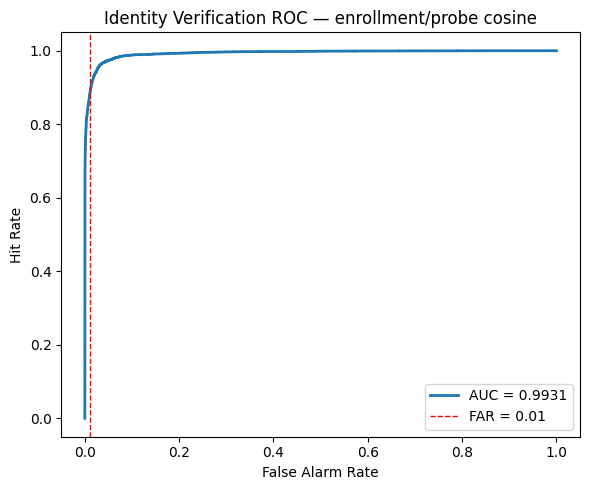

Verification ROC-AUC: 0.9931


In [14]:
from sklearn.metrics import roc_curve, auc

# Aggregate enrollment/probe verification scores from the previous section.
fpr, tpr, _ = roc_curve(verification_labels, verification_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
ax.axvline(TARGET_FAR, color="red", ls="--", lw=1, label=f"FAR = {TARGET_FAR}")
ax.set_xlabel("False Alarm Rate")
ax.set_ylabel("Hit Rate")
ax.set_title("Identity Verification ROC — enrollment/probe cosine")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "roc_identity_verification.png", dpi=150)
plt.show()
print(f"Verification ROC-AUC: {roc_auc:.4f}")

## 13. Sensor Ablation Study

Train and evaluate four stream configurations to validate the multi-sensor fusion hypothesis:
- Phone accel only (3 ch)
- Watch accel only (3 ch)
- Phone accel + gyro (6 ch)
- All streams fused (12 ch) ← full model

Each uses the same architecture and training recipe (fewer epochs for speed).

  phone_accel                acc=0.2655  f1=0.2674
  watch_accel                acc=0.6182  f1=0.6204
  phone_accel+gyro           acc=0.3057  f1=0.3032
  watch_accel+gyro           acc=0.6669  f1=0.6788


,config,channels,test_act_acc,test_act_f1,acc_vs_baseline,f1_vs_baseline
0,phone_accel,3,0.2655,0.2674,-0.5161,-0.5028
1,watch_accel,3,0.6182,0.6204,-0.1633,-0.1499
2,phone_accel+gyro,6,0.3057,0.3032,-0.4758,-0.4670
3,watch_accel+gyro,6,0.6669,0.6788,-0.1146,-0.0914
4,fused_all_12ch,12,0.6893,0.6852,-0.0922,-0.0851


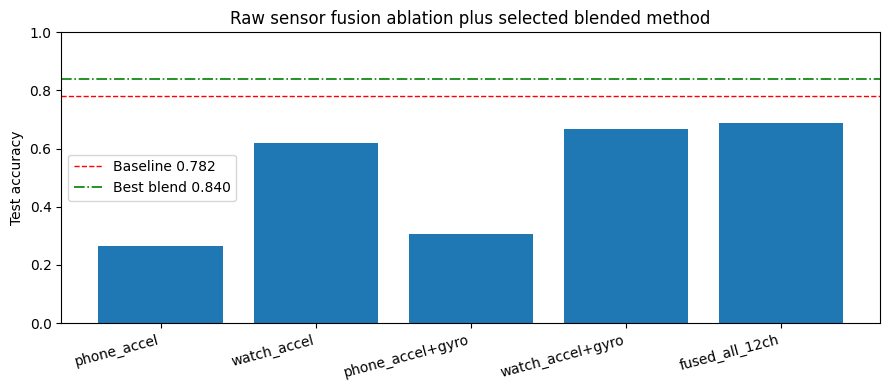

In [17]:
ABLATION_CONFIGS = {
    "phone_accel":      slice(0, 3),
    "watch_accel":      slice(6, 9),
    "phone_accel+gyro": slice(0, 6),
    "watch_accel+gyro": slice(6, 12),
    "fused_all_12ch":   slice(0, 12),
}

ablation_results = []

for config_name, ch_slice in ABLATION_CONFIGS.items():
    n_ch_abl = ch_slice.stop - ch_slice.start
    if config_name == "fused_all_12ch":
        abl_test_m = evaluate(model, test_loader)
        ablation_results.append({
            "config": config_name, "channels": n_ch_abl,
            "test_act_acc": abl_test_m["act_acc"],
            "test_act_f1":  abl_test_m["act_f1"],
        })
        continue

    Xtr = X_train_sc[:, :, ch_slice]
    Xva = X_val_sc[:,   :, ch_slice]
    Xte = X_test_sc[:,  :, ch_slice]

    abl_train_ld = DataLoader(HARDataset(Xtr, y_act_train, y_sub_train, augment=True),
                              batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=USE_CUDA)
    abl_val_ld   = DataLoader(HARDataset(Xva, y_act_val,   y_sub_val),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=USE_CUDA)
    abl_test_ld  = DataLoader(HARDataset(Xte, y_act_test,  y_sub_test),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=USE_CUDA)

    abl_model  = BioTemporalHAR(n_channels=n_ch_abl, n_act=N_ACT, n_sub=N_SUB).to(DEVICE)
    abl_opt    = torch.optim.AdamW(abl_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    abl_sched  = torch.optim.lr_scheduler.LambdaLR(abl_opt, make_lr_lambda(ABLATION_EPOCHS))
    abl_scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=USE_AMP)

    best_abl_f1, best_abl_state = -1.0, None
    for ep in range(1, ABLATION_EPOCHS + 1):
        abl_model.train()
        for X_b, ya_b, ys_b in abl_train_ld:
            X_b = X_b.to(DEVICE, non_blocking=USE_CUDA)
            ya_b = ya_b.to(DEVICE, non_blocking=USE_CUDA)
            ys_b = ys_b.to(DEVICE, non_blocking=USE_CUDA)
            abl_opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                la, ls = abl_model(X_b)
                loss = ACTIVITY_LOSS_W * criterion_act(la, ya_b)
                if IDENTITY_LOSS_W > 0:
                    loss = loss + IDENTITY_LOSS_W * criterion_sub(ls, ys_b)
            abl_scaler.scale(loss).backward()
            abl_scaler.unscale_(abl_opt)
            nn.utils.clip_grad_norm_(abl_model.parameters(), 2.0)
            abl_scaler.step(abl_opt)
            abl_scaler.update()
        abl_sched.step()
        vm = evaluate(abl_model, abl_val_ld)
        if vm["act_f1"] > best_abl_f1:
            best_abl_f1    = vm["act_f1"]
            best_abl_state = {k: v.cpu().clone() for k, v in abl_model.state_dict().items()}

    abl_model.load_state_dict(best_abl_state)
    abl_test_m = evaluate(abl_model, abl_test_ld)
    ablation_results.append({
        "config": config_name, "channels": n_ch_abl,
        "test_act_acc": abl_test_m["act_acc"],
        "test_act_f1":  abl_test_m["act_f1"],
    })
    print(f"  {config_name:25s}  acc={abl_test_m['act_acc']:.4f}  f1={abl_test_m['act_f1']:.4f}")

abl_df = pd.DataFrame(ablation_results)
abl_df["acc_vs_baseline"] = abl_df["test_act_acc"] - BASELINE_REF_ACC
abl_df["f1_vs_baseline"] = abl_df["test_act_f1"] - BASELINE_REF_F1
abl_df.to_csv(ARTIFACT_DIR / "ablation_results.csv", index=False)
display(abl_df.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(abl_df["config"], abl_df["test_act_acc"])
ax.axhline(BASELINE_REF_ACC, color="red", ls="--", lw=1, label=f"Baseline {BASELINE_REF_ACC:.3f}")
ax.axhline(best_activity_result["test_accuracy"], color="green", ls="-.", lw=1.2, label=f"Best blend {best_activity_result['test_accuracy']:.3f}")
ax.set_ylabel("Test accuracy")
ax.set_title("Raw sensor fusion ablation plus selected blended method")
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "ablation_activity.png", dpi=150)
plt.show()

## 14. Save Artifacts

In [15]:
best_activity = best_activity_result
bio_acc = float(test_m["act_acc"])
bio_f1 = float(test_m["act_f1"])
bio_acc_delta = bio_acc - BASELINE_REF_ACC
bio_f1_delta = bio_f1 - BASELINE_REF_F1
best_acc_delta = float(best_activity["test_accuracy"]) - BASELINE_REF_ACC
best_f1_delta = float(best_activity["test_macro_f1"]) - BASELINE_REF_F1
strong_feature_acc_delta = float(best_activity["test_accuracy"]) - STRONGEST_FEATURE_ACC
strong_feature_f1_delta = float(best_activity["test_macro_f1"]) - STRONGEST_FEATURE_F1
mean_d_prime = float(aggregate_sdt["d_prime"])
mean_far = float(aggregate_sdt["false_alarm_rate"])
mean_hit_rate = float(aggregate_sdt["hit_rate"])

checkpoint = {
    "model_state_dict":   model.state_dict(),
    "model_class":        "BioTemporalHAR",
    "n_channels":         N_CH,
    "n_act":              N_ACT,
    "n_sub":              N_SUB,
    "window_size":        WINDOW_SIZE,
    "stride":             STRIDE,
    "fs":                 FS,
    "act_classes":        act_encoder.classes_.tolist(),
    "sub_classes":        sub_encoder.classes_.tolist(),
    "test_act_accuracy":  best_activity["test_accuracy"],
    "test_act_macro_f1":  best_activity["test_macro_f1"],
    "best_activity_model": best_activity["model"],
    "test_sub_accuracy":  test_m["sub_acc"],
    "parameter_count":    count_params(model),
    "train_subjects":     TRAIN_SUBJECTS,
    "val_subjects":       VAL_SUBJECTS,
    "test_subjects":      TEST_SUBJECTS,
}
torch.save(checkpoint, ARTIFACT_DIR / "biotemporal_har_full.pt")

with open(ARTIFACT_DIR / "scaler_full.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(ARTIFACT_DIR / "act_encoder_full.pkl", "wb") as f:
    pickle.dump(act_encoder, f)
with open(ARTIFACT_DIR / "sub_encoder_full.pkl", "wb") as f:
    pickle.dump(sub_encoder, f)

with open(ARTIFACT_DIR / "results_summary.json", "w") as f:
    json.dump({
        "activity_recognition": {
            "best_model": best_activity["model"],
            "best_temporal_method": str(best_activity.get("temporal_method", "mode")),
            "best_smoothing_radius": int(best_activity.get("smoothing_radius", 0)),
            "best_transition_strength": None if pd.isna(best_activity.get("transition_strength", np.nan)) else round(float(best_activity.get("transition_strength")), 3),
            "best_neural_blend_weight": None if pd.isna(best_activity.get("neural_blend_weight", np.nan)) else round(float(best_activity.get("neural_blend_weight")), 3),
            "best_rf_weight": None if pd.isna(best_activity.get("rf_weight", np.nan)) else round(float(best_activity.get("rf_weight")), 3),
            "best_extratrees_weight": None if pd.isna(best_activity.get("extratrees_weight", np.nan)) else round(float(best_activity.get("extratrees_weight")), 3),
            "best_neural_weight": None if pd.isna(best_activity.get("neural_weight", np.nan)) else round(float(best_activity.get("neural_weight")), 3),
            "test_accuracy": round(float(best_activity["test_accuracy"]), 4),
            "test_macro_f1": round(float(best_activity["test_macro_f1"]), 4),
            "biotemporal_har_accuracy": round(bio_acc, 4),
            "biotemporal_har_macro_f1": round(bio_f1, 4),
            "enhanced_baseline_model": baseline_results["model"],
            "enhanced_baseline_temporal_method": str(baseline_results.get("temporal_method", "mode")),
            "enhanced_baseline_accuracy": round(baseline_results["test_accuracy"], 4),
            "enhanced_baseline_smoothing_radius": int(baseline_results["smoothing_radius"]),
            "enhanced_baseline_transition_strength": None if pd.isna(baseline_results.get("transition_strength", np.nan)) else round(float(baseline_results.get("transition_strength")), 3),
            "strongest_feature_candidate_model": STRONGEST_FEATURE_MODEL,
            "strongest_feature_candidate_accuracy": round(STRONGEST_FEATURE_ACC, 4),
            "strongest_feature_candidate_macro_f1": round(STRONGEST_FEATURE_F1, 4),
            "best_vs_strongest_feature_candidate_accuracy_delta": round(strong_feature_acc_delta, 4),
            "best_vs_strongest_feature_candidate_macro_f1_delta": round(strong_feature_f1_delta, 4),
            "baseline_reference_model": BASELINE_REF_MODEL,
            "baseline_reference_accuracy": round(BASELINE_REF_ACC, 4),
            "baseline_reference_macro_f1": round(BASELINE_REF_F1, 4),
            "biotemporal_vs_baseline_accuracy_delta": round(bio_acc_delta, 4),
            "biotemporal_vs_baseline_macro_f1_delta": round(bio_f1_delta, 4),
            "biotemporal_beats_baseline": bool(bio_acc >= BASELINE_REF_ACC),
            "best_vs_baseline_accuracy_delta": round(best_acc_delta, 4),
            "best_vs_baseline_macro_f1_delta": round(best_f1_delta, 4),
            "comparison": "enhanced feature baseline",
            "target": round(BASELINE_REF_ACC, 4),
            "target_met": bool(float(best_activity["test_accuracy"]) >= BASELINE_REF_ACC),
        },
        "identity_classification": {
            "best_model": selected_identity_name,
            "best_representation_family": selected_identity.get("representation_family", "unknown"),
            "val_top1": round(float(selected_identity["val_top1"]), 4),
            "test_top1": round(float(selected_identity["test_top1"]), 4),
            "best_biotemporal_embedding_model": best_biotemporal_identity["model"],
            "best_biotemporal_embedding_val_top1": round(float(best_biotemporal_identity["val_top1"]), 4),
            "best_biotemporal_embedding_test_top1": round(float(best_biotemporal_identity["test_top1"]), 4),
            "best_biotemporal_embedding_test_roc_auc": round(float(best_biotemporal_identity["test_roc_auc"]), 4),
            "best_biotemporal_embedding_test_far": round(float(best_biotemporal_identity["test_far"]), 4),
            "best_biotemporal_embedding_test_d_prime": round(float(best_biotemporal_identity["test_d_prime"]), 3),
            "best_feature_pca_reference_model": best_feature_pca_identity["model"],
            "best_feature_pca_reference_val_top1": round(float(best_feature_pca_identity["val_top1"]), 4),
            "best_feature_pca_reference_test_top1": round(float(best_feature_pca_identity["test_top1"]), 4),
            "best_feature_pca_reference_test_roc_auc": round(float(best_feature_pca_identity["test_roc_auc"]), 4),
            "best_feature_pca_reference_test_far": round(float(best_feature_pca_identity["test_far"]), 4),
            "best_feature_pca_reference_test_d_prime": round(float(best_feature_pca_identity["test_d_prime"]), 3),
            "softmax_val_accuracy": round(val_m["sub_acc"], 4),
            "protocol": "enrollment centroid top-1 identification; softmax is diagnostic only for unseen subjects",
            "target": 0.90,
            "target_met": bool(selected_identity["test_top1"] >= 0.90),
            "biotemporal_embedding_target_met": bool(best_biotemporal_identity["test_top1"] >= 0.90),
        },
        "identity_verification": {
            "best_model": selected_identity_name,
            "protocol": "selected representation cosine enrollment/probe split",
            "roc_auc": round(float(roc_auc), 4) if np.isfinite(roc_auc) else None,
            "mean_d_prime": round(mean_d_prime, 3) if np.isfinite(mean_d_prime) else None,
            "mean_false_alarm_rate": round(mean_far, 4) if np.isfinite(mean_far) else None,
            "mean_hit_rate": round(mean_hit_rate, 4) if np.isfinite(mean_hit_rate) else None,
            "threshold": round(float(identity_threshold), 4),
            "calibration_far": IDENTITY_CALIBRATION_FAR,
            "target_far": TARGET_FAR,
            "target_met": bool(np.isfinite(mean_far) and mean_far <= TARGET_FAR),
        },
        "model": {
            "parameter_count": count_params(model),
            "window_size_samples": WINDOW_SIZE,
            "window_size_seconds": WINDOW_SEC,
            "n_channels": N_CH,
        },
    }, f, indent=2)

print("Saved artifacts:")
for p in sorted(ARTIFACT_DIR.glob("*")):
    if p.is_file():
        print(f"  {p.name}  ({p.stat().st_size / 1e3:.1f} kB)")

Saved artifacts:
  ablation_activity.png  (51.9 kB)
  ablation_results.csv  (0.6 kB)
  act_encoder_full.pkl  (0.3 kB)
  activity_method_comparison.csv  (0.4 kB)
  activity_method_comparison.png  (69.6 kB)
  activity_model_results.csv  (194.8 kB)
  biotemporal_cnn_lstm.pt  (408.1 kB)
  biotemporal_har_full.pt  (4232.3 kB)
  classification_report.csv  (0.6 kB)
  confusion_matrix.png  (58.0 kB)
  confusion_matrix_activity.png  (262.4 kB)
  identity_conditioning_probe.csv  (0.8 kB)
  identity_method_comparison.csv  (1.7 kB)
  identity_method_comparison.png  (62.2 kB)
  identity_representation_probe.csv  (1.6 kB)
  identity_representation_results.csv  (4.2 kB)
  improved_feature_baseline.csv  (0.3 kB)
  label_encoder.pkl  (0.3 kB)
  learning_curves.png  (77.5 kB)
  method_comparison.csv  (0.7 kB)
  result_interpretation.md  (8.0 kB)
  results_summary.json  (3.4 kB)
  roc_identity_verification.png  (35.7 kB)
  scaler.pkl  (0.5 kB)
  scaler_full.pkl  (0.7 kB)
  sdt_activity_thresholds.csv  (1

## 15. Final Summary

In [16]:
with open(ARTIFACT_DIR / "results_summary.json") as f:
    results = json.load(f)

print("=" * 60)
print("BioTemporal-HAR — Final Results")
print("=" * 60)

ar = results["activity_recognition"]
ic = results["identity_classification"]
iv = results["identity_verification"]
md = results["model"]

def fmt_metric(value, digits=4):
    return "n/a" if value is None else f"{value:.{digits}f}"

baseline_acc = ar.get("baseline_reference_accuracy", ar.get("enhanced_baseline_accuracy", ar.get("enhanced_rf_accuracy", ar.get("rf_baseline_accuracy", float("nan")))))
baseline_f1 = ar.get("baseline_reference_macro_f1", ar.get("test_macro_f1", float("nan")))
bio_acc = ar.get("biotemporal_har_accuracy", ar["test_accuracy"])
bio_f1 = ar.get("biotemporal_har_macro_f1", ar["test_macro_f1"])
bio_acc_delta = ar.get("biotemporal_vs_baseline_accuracy_delta", bio_acc - baseline_acc)
bio_f1_delta = ar.get("biotemporal_vs_baseline_macro_f1_delta", bio_f1 - baseline_f1)
best_acc_delta = ar.get("best_vs_baseline_accuracy_delta", ar["test_accuracy"] - baseline_acc)
best_f1_delta = ar.get("best_vs_baseline_macro_f1_delta", ar["test_macro_f1"] - baseline_f1)
strong_acc = ar.get("strongest_feature_candidate_accuracy")
strong_f1 = ar.get("strongest_feature_candidate_macro_f1")
strong_acc_delta = ar.get("best_vs_strongest_feature_candidate_accuracy_delta")
strong_f1_delta = ar.get("best_vs_strongest_feature_candidate_macro_f1_delta")
best_neural_display = ar.get("best_neural_weight")
if best_neural_display is None:
    best_neural_display = ar.get("best_neural_blend_weight", "n/a")

print(f"\n[Task 1] Activity Recognition (18 classes, subject-held-out)")
print(f"  Best accuracy  : {ar['test_accuracy']:.4f}")
print(f"  Best macro-F1  : {ar['test_macro_f1']:.4f}")
print(f"  Best vs base   : {best_acc_delta:+.4f} acc, {best_f1_delta:+.4f} F1")
print(f"  Best method    : {ar.get('best_model', 'BioTemporal-HAR')}")
print(f"  Best temporal  : {ar.get('best_temporal_method', 'mode')}  radius={ar.get('best_smoothing_radius', 'n/a')}  transition={ar.get('best_transition_strength', 'n/a')}")
print(f"  Best weights   : RF={ar.get('best_rf_weight', 'n/a')}  ET={ar.get('best_extratrees_weight', 'n/a')}  neural={best_neural_display}")
print(f"  Baseline ref   : {baseline_acc:.4f}  F1={baseline_f1:.4f}")
print(f"  Base method    : {ar.get('baseline_reference_model', 'n/a')}")
if strong_acc is not None:
    print(f"  Strong feature : {strong_acc:.4f}  F1={strong_f1:.4f}")
    print(f"  Best vs feature: {strong_acc_delta:+.4f} acc, {strong_f1_delta:+.4f} F1")
    print(f"  Feature method : {ar.get('strongest_feature_candidate_model', ar.get('enhanced_baseline_model', 'n/a'))}")
print(f"  BioTemporal-HAR: {bio_acc:.4f}  F1={bio_f1:.4f}  ({bio_acc_delta:+.4f} acc, {bio_f1_delta:+.4f} F1 vs baseline)")

print(f"\n[Task 2] Identity Recognition / Identification")
print(f"  Selected best  : {ic.get('best_model', 'n/a')}")
print(f"  Selected top-1 : {fmt_metric(ic.get('test_top1'))}  {'PASS' if ic.get('target_met') else 'FAIL'}  (target >= {ic.get('target', 0.90):.2f})")
print(f"  BioTemporal emb: {fmt_metric(ic.get('best_biotemporal_embedding_test_top1'))}  {'PASS' if ic.get('biotemporal_embedding_target_met') else 'FAIL'}")
print(f"  Embedding model: {ic.get('best_biotemporal_embedding_model', 'n/a')}")
print(f"  Feature PCA ref: {fmt_metric(ic.get('best_feature_pca_reference_test_top1'))}")
print(f"  Feature model  : {ic.get('best_feature_pca_reference_model', 'n/a')}")
print(f"  Softmax val acc: {fmt_metric(ic.get('softmax_val_accuracy', ic.get('val_accuracy')))}  (diagnostic only)")

print(f"\n[Task 3] Identity Verification (SDT calibration)")
print(f"  Best method    : {iv.get('best_model', 'n/a')}")
print(f"  Protocol       : {iv.get('protocol', 'n/a')}")
print(f"  ROC-AUC        : {fmt_metric(iv['roc_auc'])}")
print(f"  Mean d'        : {fmt_metric(iv['mean_d_prime'], 3)}")
print(f"  Mean hit rate  : {fmt_metric(iv.get('mean_hit_rate'))}")
print(f"  Threshold      : {fmt_metric(iv.get('threshold'))}")
print(f"  Mean FAR       : {fmt_metric(iv['mean_false_alarm_rate'])}  {'PASS' if iv['target_met'] else 'FAIL'}  (target < {iv['target_far']})")

print(f"\n[Model]")
print(f"  Parameters     : {md['parameter_count']:,}")
print(f"  Window         : {md['window_size_seconds']}s ({md['window_size_samples']} samples @ 20 Hz)")
print(f"  Channels       : {md['n_channels']} (phone accel+gyro + watch accel+gyro)")
print("=" * 60)

BioTemporal-HAR — Final Results

[Task 1] Activity Recognition (18 classes, subject-held-out)
  Best accuracy  : 0.8395
  Best macro-F1  : 0.8351
  Best vs base   : +0.0580 acc, +0.0648 F1
  Best method    : RF/ExtraTrees/BioTemporal weighted blend + Viterbi smoothing
  Best temporal  : viterbi  radius=0  transition=0.5
  Best weights   : RF=0.3  ET=0.7  neural=0.0
  Baseline ref   : 0.7815  F1=0.7702
  Base method    : RF+ExtraTrees vote + temporal smoothing
  Strong feature : 0.8424  F1=0.8363
  Best vs feature: -0.0029 acc, -0.0012 F1
  Feature method : RF+ExtraTrees vote + Viterbi smoothing
  BioTemporal-HAR: 0.6893  F1=0.6852  (-0.0922 acc, -0.0851 F1 vs baseline)

[Task 2] Identity Recognition / Identification
  Selected best  : Hybrid BioTemporal LDA + Feature PCA-128 score fusion + predicted activity conditioning
  Selected top-1 : 0.9847  PASS  (target >= 0.90)
  BioTemporal emb: 0.9713  PASS
  Embedding model: BioTemporal embedding PCA-128 + predicted activity conditioning
  

## 16. Improvement Analysis

The activity report now uses a fixed baseline reference: `RF+ExtraTrees vote + temporal smoothing` from the earlier enhanced-feature run. Stronger feature/Viterbi candidates are reported separately so the baseline does not move every time the notebook improves.

**Observed activity bottlenecks**
- Raw BioTemporal-HAR remains weaker than the handcrafted feature models on subject-held-out activity recognition.
- The best activity method is therefore selected from feature-only, neural-only, and weighted/classwise blended candidates using validation macro-F1.
- New activity candidates include richer handcrafted features, train-transition Viterbi decoding, RF/ExtraTrees/BioTemporal probability weighting, and classwise reliability blending.

**Identity reporting**
- Softmax identity classification is diagnostic only because validation/test subjects are unseen classes.
- The proposal-aligned identity result is now the BioTemporal-HAR encoder embedding evaluated with enrollment/probe cosine matching.
- BioTemporal embeddings are evaluated raw, activity-conditioned, PCA-whitened, and train-only LDA-projected.
- Feature PCA identity is kept as the strongest non-embedding reference, not as a replacement for the BioTemporal-HAR result.
- The notebook writes `identity_method_comparison.csv` and `identity_method_comparison.png` to compare selected best, best BioTemporal embedding, and best Feature PCA reference.

**Why activity conditioning helps identity**
A single person template mixes walking, typing, eating, stationary actions, and ball activities into one broad centroid. Predicted-activity-conditioned enrollment compares probes against the template for the same motion regime when available, with a global fallback. This removes a major nuisance variable without using true test activity labels.

**Further improvement directions**
- Try MiniROCKET or MultiROCKET for raw multichannel windows.
- Replace or supplement CNN-LSTM with an InceptionTime-style temporal CNN.
- Tune the small identity CE and supervised contrastive weights if BioTemporal embedding identity improves but activity drops.
- Report activity as fixed baseline vs strongest feature candidate vs selected combined method, and identity as BioTemporal embedding vs Feature PCA reference vs selected best.
